# Lab 2: RBFs, CL & SOMs

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'STIXGeneral'

## 3 Part I.

### 3.1 Batch mode training using least squares - supervised learning of network weights

Approximating two functions:
-  $f_1(x) = \sin(x)$
- $f_2(x) = \text{sgn}(\sin(2x))$

#### Generating and plotting input data points

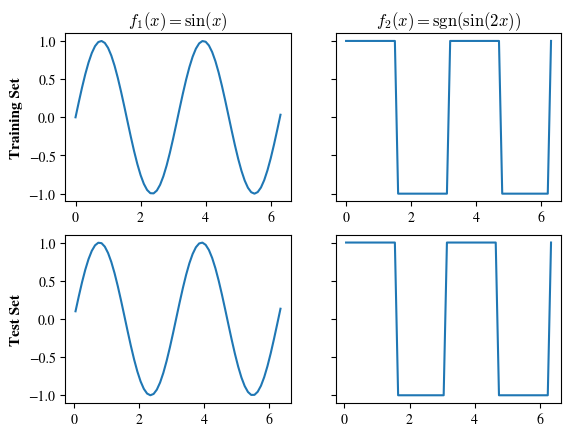

In [2]:
train_set = np.arange(0, 2 * np.pi + 0.1, step=0.1)
test_set = np.arange(0.05, 2 * np.pi + 0.1, step=0.1)

f2 = lambda x: np.where(np.sin(2*x) >= 0, 1.0, -1.0)

f_1_train = np.sin(2 * train_set)
f_2_train = f2(train_set)

f_1_test = np.sin(2 * test_set)
f_2_test = f2(test_set)

fig, (ax1, ax2) = plt.subplots(2, 2, sharey=True)

ax1[0].plot(train_set, f_1_train)
ax1[0].set_title(r"$f_1(x) = \sin(x)$")
ax1[1].plot(train_set, f_2_train)
ax1[1].set_title(r"$f_2(x) = \text{sgn}(\sin(2x))$")

ax2[0].plot(test_set, f_1_test)
ax2[1].plot(test_set, f_2_test)

ax1[0].set_ylabel("Training Set", fontsize=11, fontweight="bold")
ax2[0].set_ylabel("Test Set", fontsize=11, fontweight="bold")

fig.show()

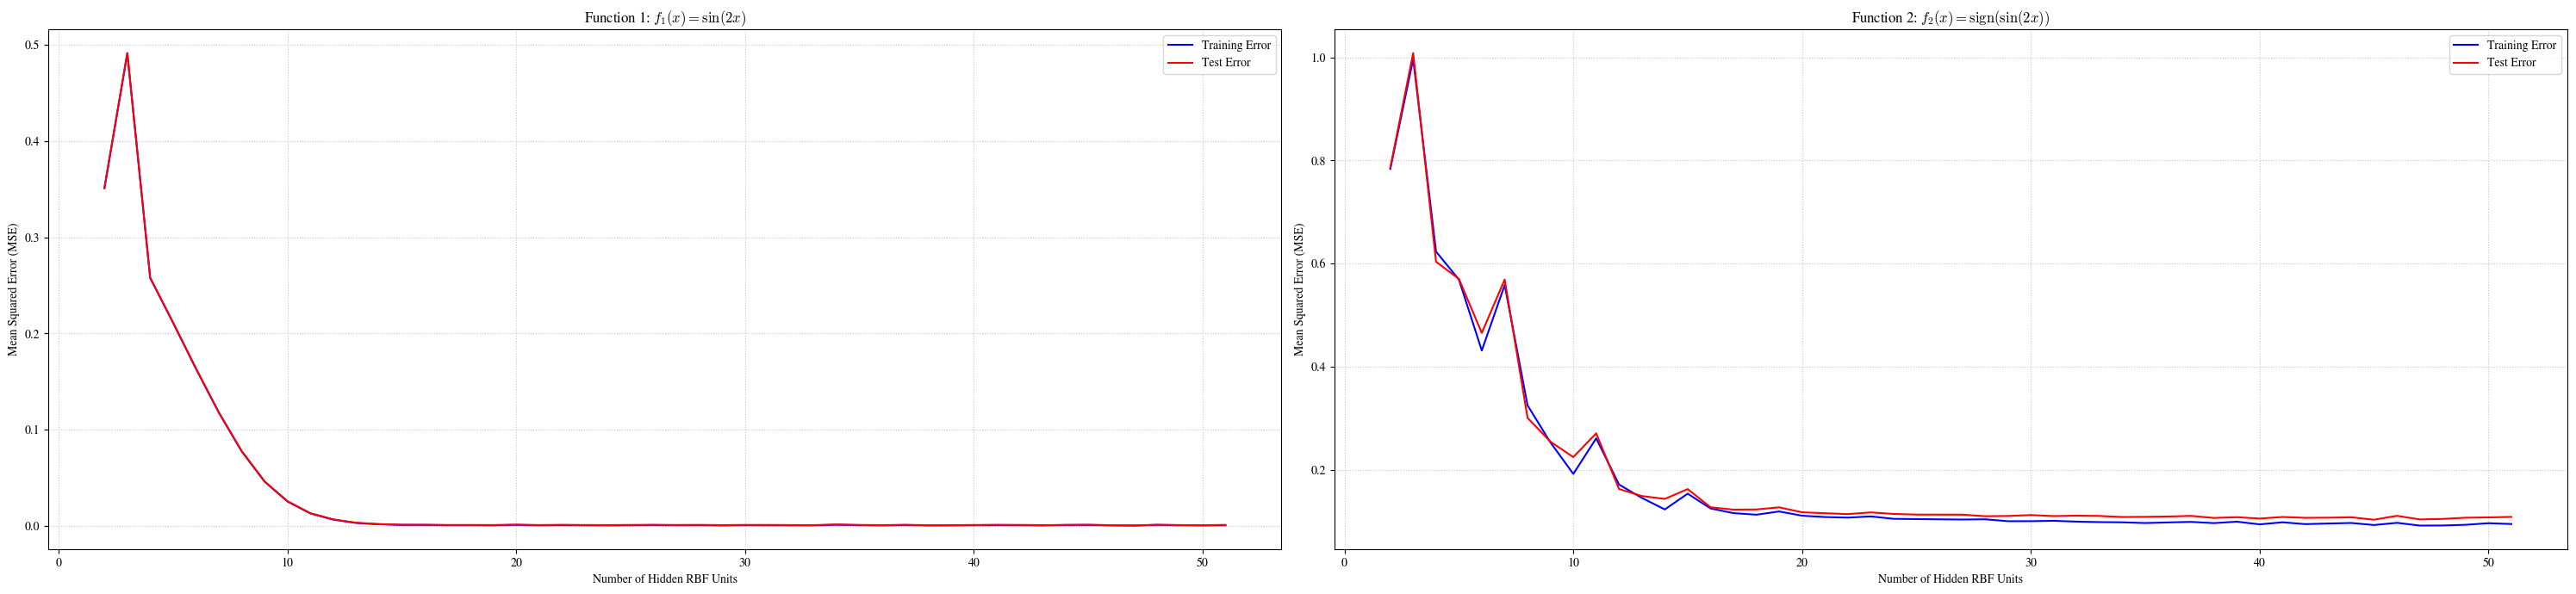

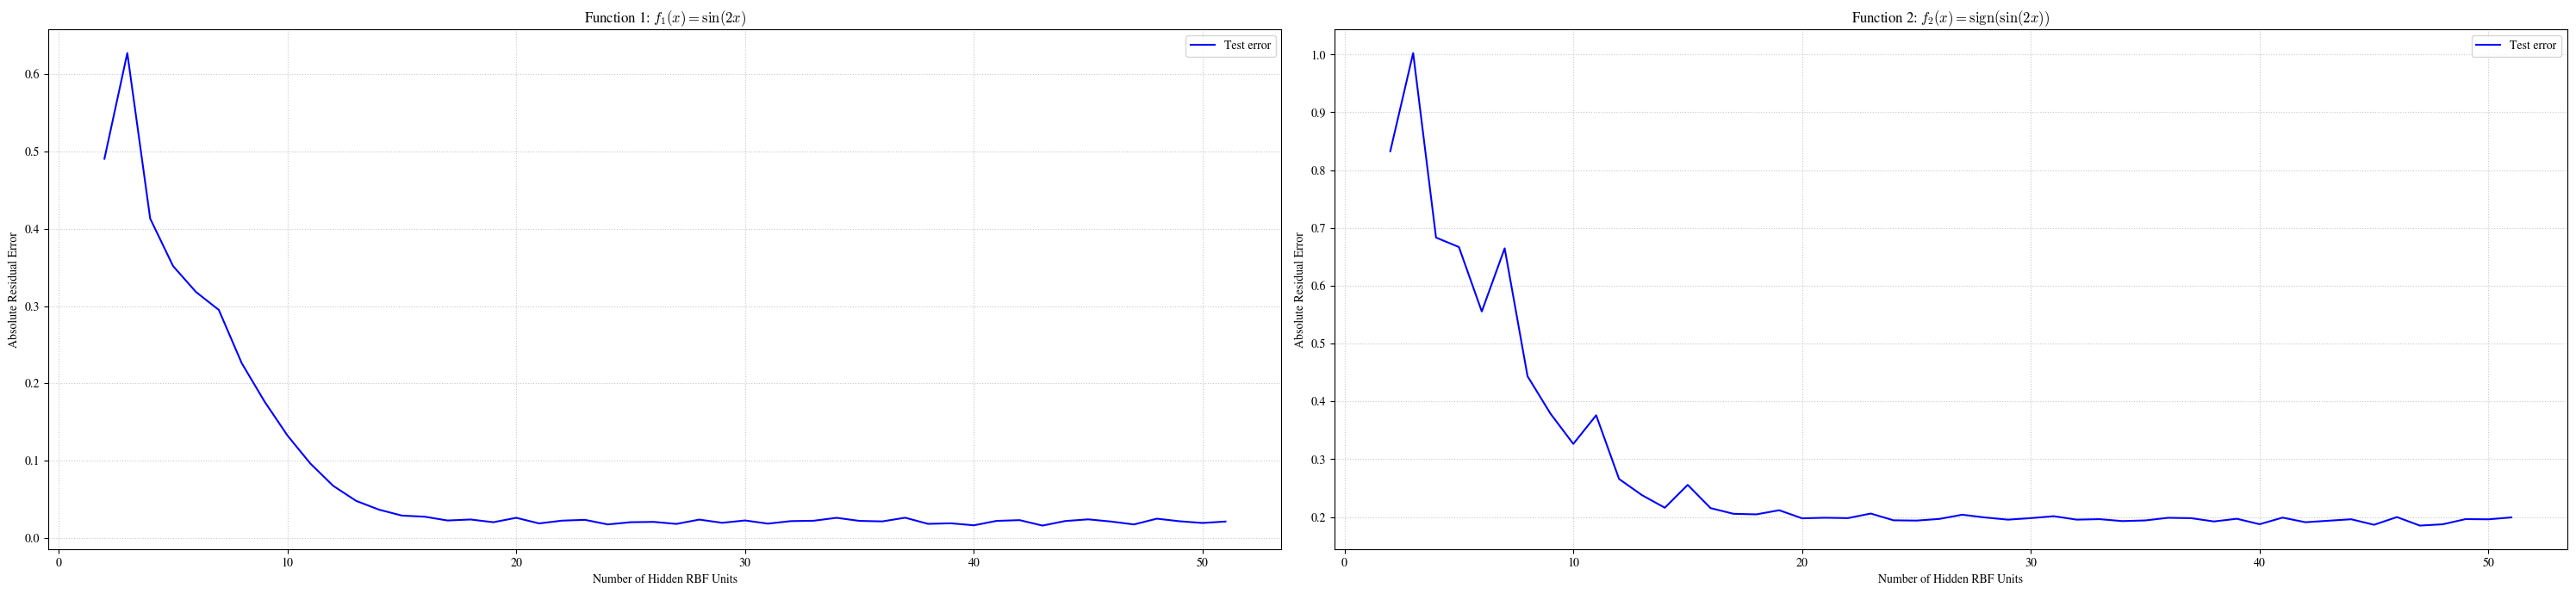

/tmp/ipykernel_61/3426986686.py:212: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes3[0].legend(fontsize=10)
/tmp/ipykernel_61/3426986686.py:224: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes3[1].legend(fontsize=10)


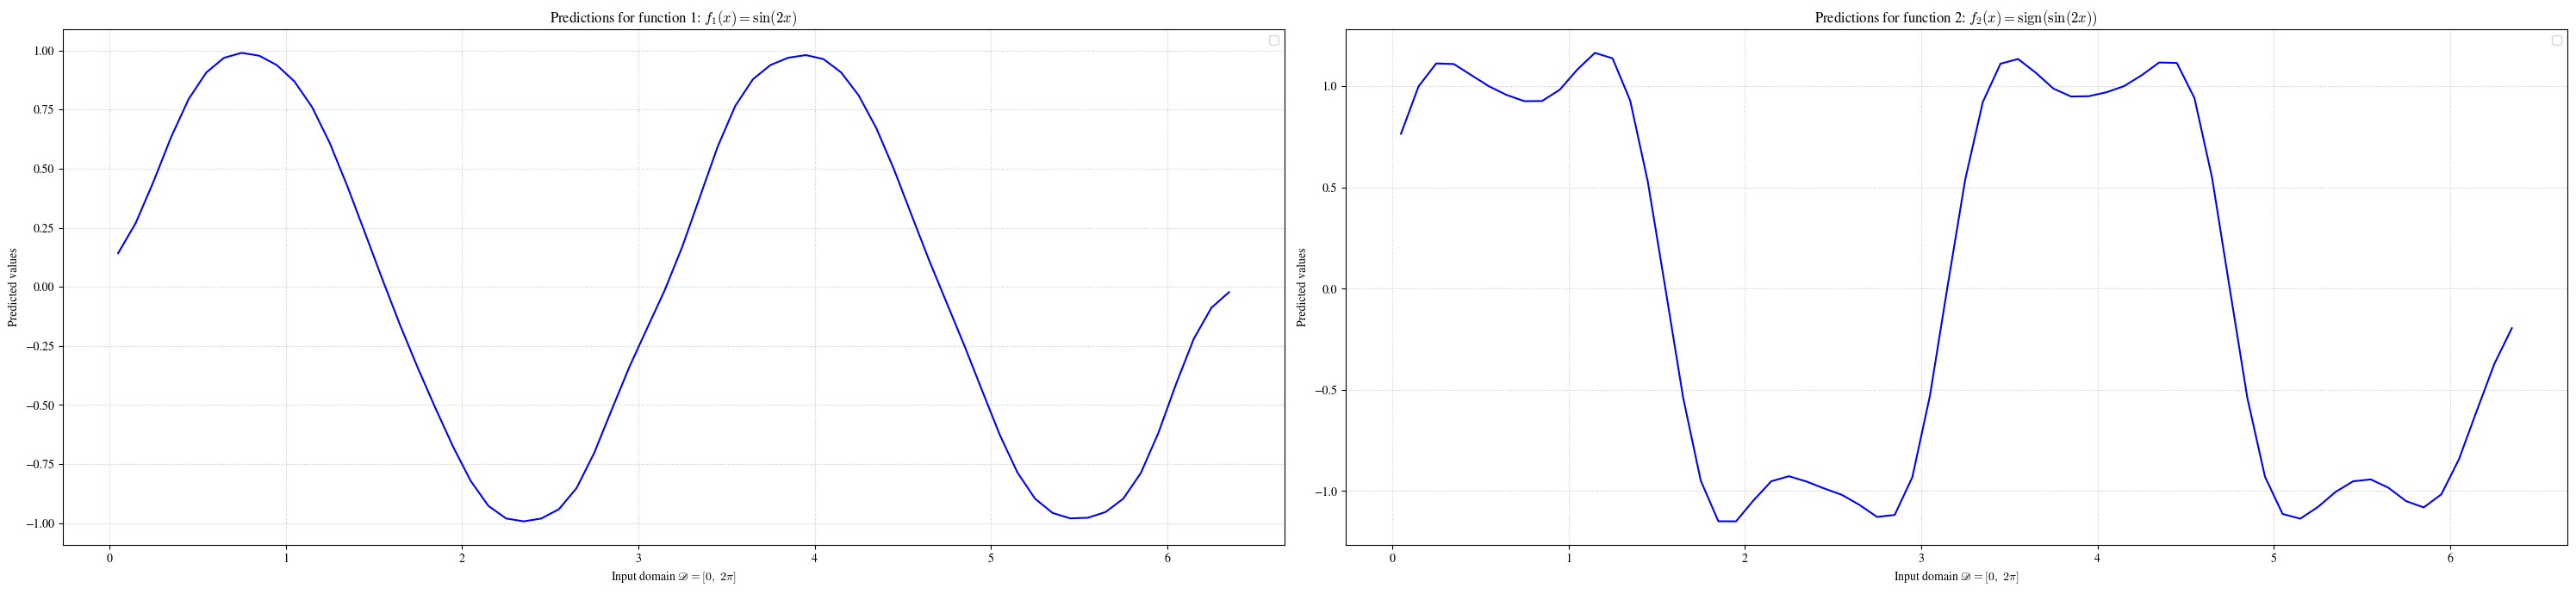

/tmp/ipykernel_61/3426986686.py:263: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes4[1].legend(fontsize=10)


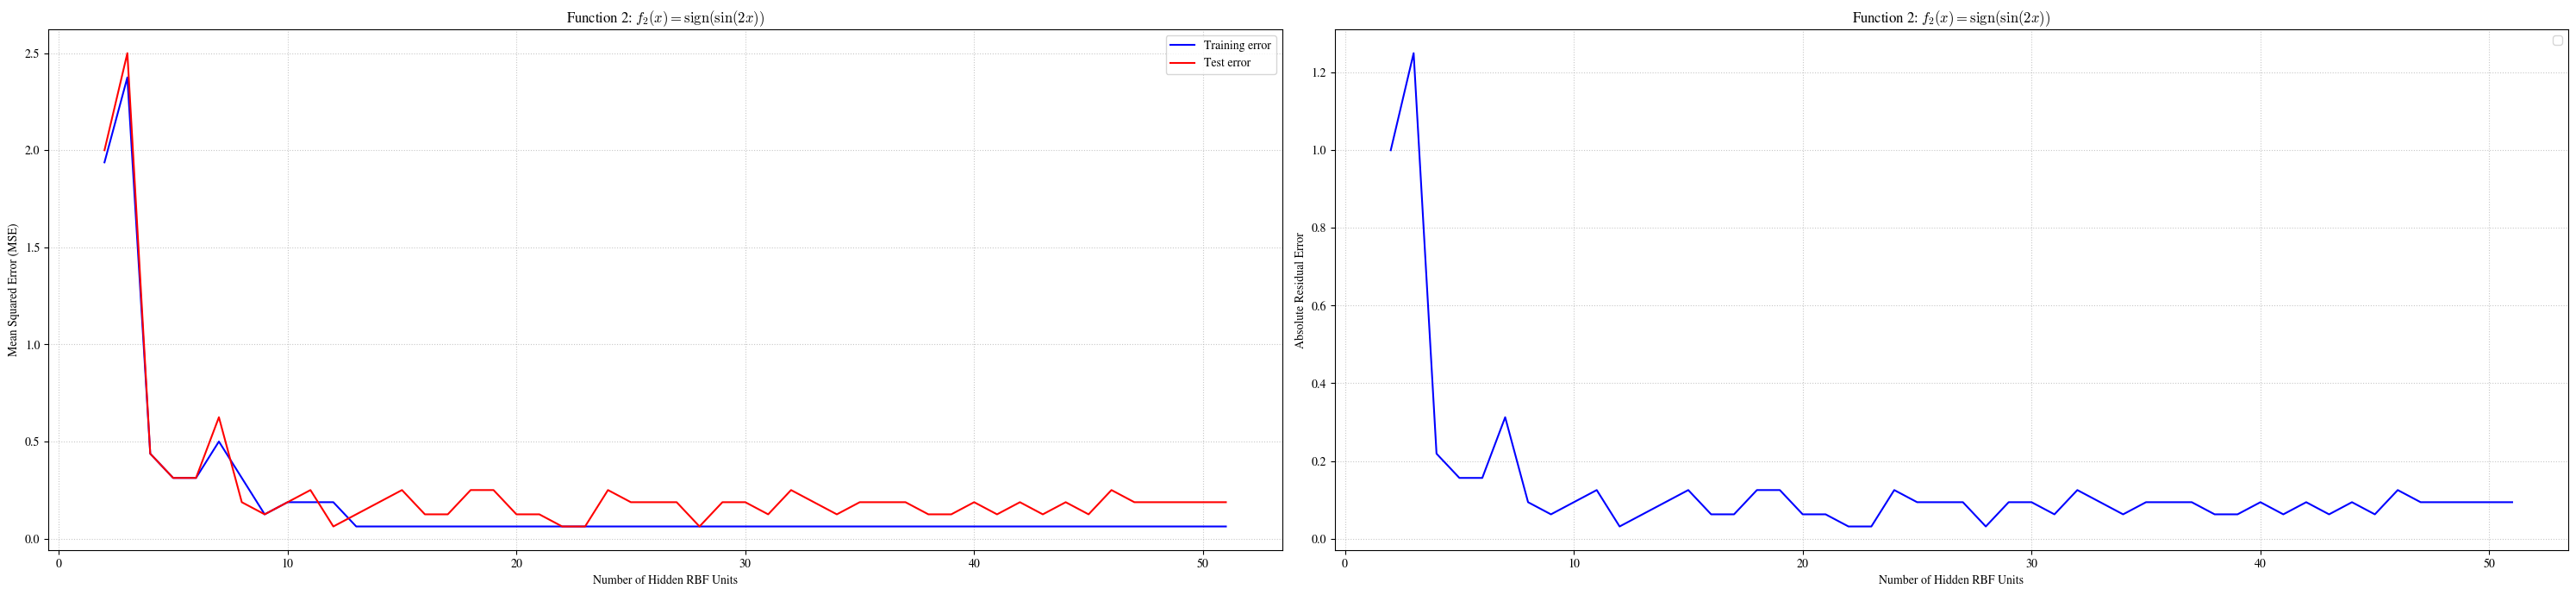

/tmp/ipykernel_61/3426986686.py:283: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes5.legend(fontsize=10)


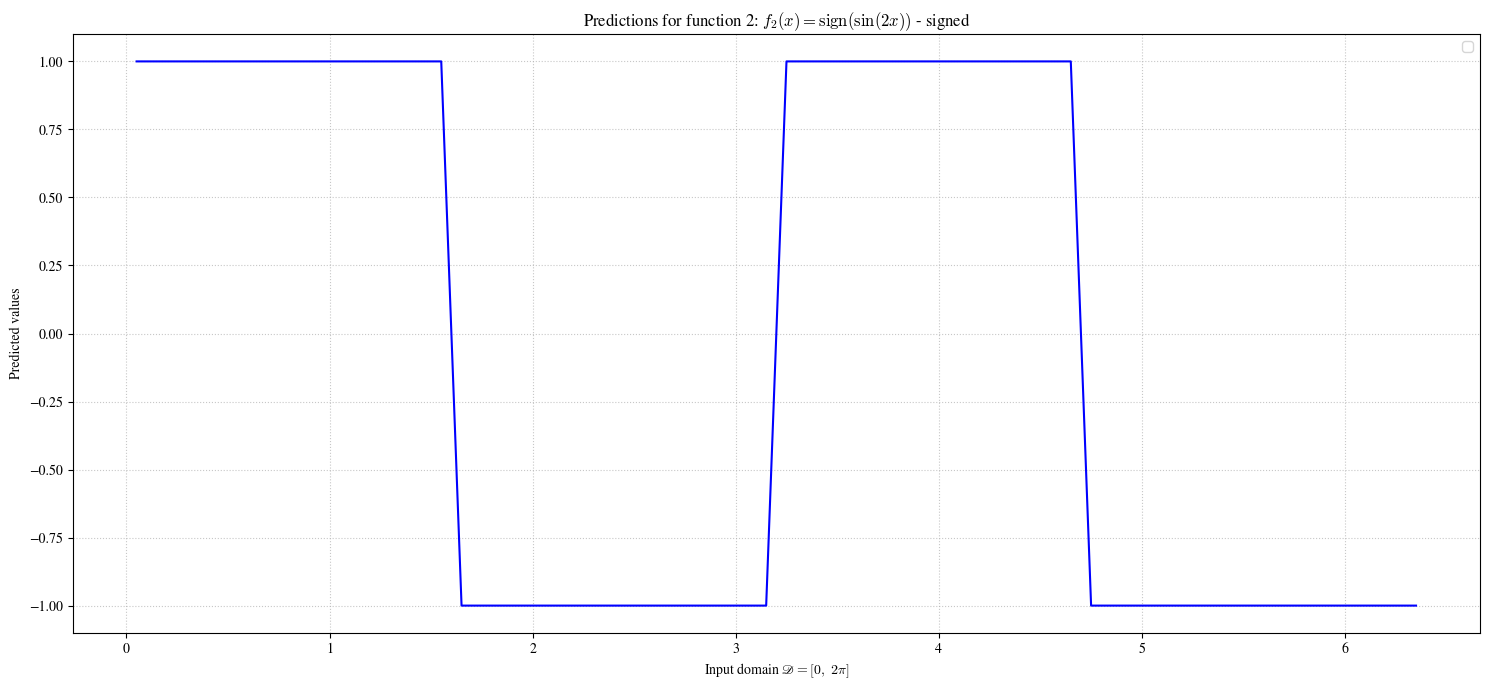

f1 stats:
Absolute Residual Error < 0.1 achieved at 11 RBF units


Absolute Residual Error < 0.01 was NOT achieved with any of 50 RBF layer sizes.


Absolute Residual Error < 0.001 was NOT achieved with any of 50 RBF layer sizes.


f2 stats:
Absolute Residual Error < 0.1 achieved at 8 RBF units


Absolute Residual Error < 0.01 was NOT achieved with any of 50 RBF layer sizes.


Absolute Residual Error < 0.001 was NOT achieved with any of 50 RBF layer sizes.




In [3]:
RBF_layer_sizes = np.arange(2, 52, step=1)
domain_range = 2 * np.pi
sigma = 0.2
EPOCHS = 4000
lr = 0.01

def gaussian_RBF(distances, sigma):
    return np.exp(- (np.square(distances) / (2 * sigma ** 2)))

def compute_phi(x_input, centers, sigma):
    distances = np.abs(x_input - centers)
    return gaussian_RBF(distances, sigma)

X_train = train_set.reshape(-1, 1)
X_test = test_set.reshape(-1, 1)

training_error_1, test_error_1 = [], []
training_error_2, test_error_2 = [], []
training_error_22, test_error_22 = [], []
test_abs_err_1, test_abs_err_2, test_abs_err_22 = [], [], []

best_err_1, best_err_2, best_err_22 = np.inf, np.inf, np.inf
best_W1, best_W2, best_W22 = None, None, None
best_PHI1, best_PHI2, best_PHI22 = None, None, None

summary = {
    "f1": {
        "0.1": None,
        "0.01": None,
        "0.001": None
    },
    "f2": {
            "0.1": None,
            "0.01": None,
            "0.001": None
    }
}

for RBF_size in RBF_layer_sizes:
    # Uniformly distribute centers across domain
    step_size = domain_range / (RBF_size + 1)
    centers = np.array([[i * step_size for i in range(1, RBF_size + 1)]])
    
    PHI_train = compute_phi(X_train, centers, sigma)
    PHI_test = compute_phi(X_test, centers, sigma)

    W1 = np.random.randn(1, RBF_size) * 0.1
    W2 = np.random.randn(1, RBF_size) * 0.1

    # Batch Gradient Descent
    N_train = len(train_set)
    for epoch in range(EPOCHS):
        pred_1 = W1 @ PHI_train.T
        pred_2 = W2 @ PHI_train.T

        err_1 = pred_1 - f_1_train
        err_2 = pred_2 - f_2_train
        dW1 = (1 / N_train) * (err_1 @ PHI_train)
        dW2 = (1 / N_train) * (err_2 @ PHI_train)

        # Update weights
        W1 -= lr * dW1
        W2 -= lr * dW2

    # Final Loss evaluation (MSE)
    train_mse_1 = np.mean((W1 @ PHI_train.T - f_1_train) ** 2)
    test_mse_1 = np.mean((W1 @ PHI_test.T - f_1_test) ** 2)
    abs_residual_1 = np.mean(np.absolute(W1 @ PHI_test.T - f_1_test))
    
    train_mse_2 = np.mean((W2 @ PHI_train.T - f_2_train) ** 2)
    test_mse_2 = np.mean((W2 @ PHI_test.T - f_2_test) ** 2)
    abs_residual_2 = np.mean(np.absolute(W2 @ PHI_test.T - f_2_test))

    train_mse_22 = np.mean((f2(W2 @ PHI_train.T) - f_2_train) ** 2)
    test_mse_22 = np.mean((f2(W2 @ PHI_test.T) - f_2_test) ** 2)
    abs_residual_22 = np.mean(np.absolute(f2(W2 @ PHI_test.T) - f_2_test))

    if train_mse_1 < best_err_1:
        best_err_1 = train_mse_1
        best_W1 = W1.copy()
        best_PHI1 =PHI_test.copy()
    
    if train_mse_2 < best_err_2:
        best_err_2 = train_mse_2
        best_W2 = W2.copy()
        best_PHI2 = PHI_test.copy()

    if train_mse_22 < best_err_22:
        best_err_22 = train_mse_22
        best_W22 = W2.copy()
        best_PHI22 = PHI_test.copy()
    
    if abs_residual_1 < 0.1 and summary["f1"]["0.1"] is None:
        summary["f1"]["0.1"] = RBF_size
    if abs_residual_1 < 0.01 and summary["f1"]["0.01"] is None:
        summary["f1"]["0.01"] = RBF_size
    if abs_residual_1 < 0.001 and summary["f1"]["0.001"] is None:
        summary["f1"]["0.001"] = RBF_size
    
    if abs_residual_22 < 0.1 and summary["f2"]["0.1"] is None:
        summary["f2"]["0.1"] = RBF_size
    if abs_residual_22 < 0.01 and summary["f2"]["0.01"] is None:
        summary["f2"]["0.01"] = RBF_size
    if abs_residual_22 < 0.001 and summary["f2"]["0.001"] is None:
        summary["f2"]["0.001"] = RBF_size

    training_error_1.append(train_mse_1)
    test_error_1.append(test_mse_1)
    test_abs_err_1.append(abs_residual_1)
    training_error_2.append(train_mse_2)
    test_error_2.append(test_mse_2)
    test_abs_err_2.append(abs_residual_2)
    training_error_22.append(train_mse_22)
    test_error_22.append(test_mse_22)
    test_abs_err_22.append(abs_residual_22)



fig1, axes1 = plt.subplots(1, 2, figsize=(30, 7))

axes1[0].plot(
    RBF_layer_sizes,
    training_error_1,
    label="Training Error",
    color="blue",
    linewidth=1.5,
)
axes1[0].plot(
    RBF_layer_sizes,
    test_error_1,
    label="Test Error",
    color="red",
    linewidth=1.5,
)
axes1[0].set_title(r"Function 1: $f_1(x) = \sin(2x)$", fontsize=12)
axes1[0].set_xlabel("Number of Hidden RBF Units", fontsize=10)
axes1[0].set_ylabel("Mean Squared Error (MSE)", fontsize=10)
axes1[0].grid(True, linestyle=":", alpha=0.7)
axes1[0].legend(fontsize=10)

axes1[1].plot(
    RBF_layer_sizes,
    training_error_2,
    label="Training Error",
    color="blue",
    linewidth=1.5,
)
axes1[1].plot(
    RBF_layer_sizes,
    test_error_2,
    label="Test Error",
    color="red",
    linewidth=1.5,
)
axes1[1].set_title(r"Function 2: $f_2(x) = \text{sign}(\sin(2x))$", fontsize=12)
axes1[1].set_xlabel("Number of Hidden RBF Units", fontsize=10)
axes1[1].set_ylabel("Mean Squared Error (MSE)", fontsize=10)
axes1[1].grid(True, linestyle=":", alpha=0.7)
axes1[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

# Figure 2: Absolute Residual Error
fig2, axes2 = plt.subplots(1, 2, figsize=(30, 7))

axes2[0].plot(
    RBF_layer_sizes,
    test_abs_err_1,
    label="Test error",
    color="blue",
    linewidth=1.5,
)
axes2[0].set_title(r"Function 1: $f_1(x) = \sin(2x)$", fontsize=12)
axes2[0].set_xlabel("Number of Hidden RBF Units", fontsize=10)
axes2[0].set_ylabel("Absolute Residual Error", fontsize=10)
axes2[0].grid(True, linestyle=":", alpha=0.7)
axes2[0].legend(fontsize=10)

axes2[1].plot(
    RBF_layer_sizes,
    test_abs_err_2,
    label="Test error",
    color="blue",
    linewidth=1.5,
)
axes2[1].set_title(r"Function 2: $f_2(x) = \text{sign}(\sin(2x))$", fontsize=12)
axes2[1].set_xlabel("Number of Hidden RBF Units", fontsize=10)
axes2[1].set_ylabel("Absolute Residual Error", fontsize=10)
axes2[1].grid(True, linestyle=":", alpha=0.7)
axes2[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

# Figure 3: Predictions on Test Set
pred_1 = (best_W1 @ best_PHI1.T).flatten()
pred_2 = (best_W2 @ best_PHI2.T).flatten()

fig3, axes3 = plt.subplots(1, 2, figsize=(30, 7))

axes3[0].plot(
    test_set,
    pred_1,
    color="blue",
    linewidth=1.5,
)
axes3[0].set_title(r"Predictions for function 1: $f_1(x) = \sin(2x)$", fontsize=12)
axes3[0].set_xlabel(r"Input domain $\mathscr{D}=[0,\;2\pi]$", fontsize=10)
axes3[0].set_ylabel("Predicted values", fontsize=10)
axes3[0].grid(True, linestyle=":", alpha=0.7)
axes3[0].legend(fontsize=10)

axes3[1].plot(
    test_set,
    pred_2,
    color="blue",
    linewidth=1.5,
)
axes3[1].set_title(r"Predictions for function 2: $f_2(x) = \text{sign}(\sin(2x))$", fontsize=12)
axes3[1].set_xlabel(r"Input domain $\mathscr{D}=[0,\;2\pi]$", fontsize=10)
axes3[1].set_ylabel("Predicted values", fontsize=10)
axes3[1].grid(True, linestyle=":", alpha=0.7)
axes3[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

# Figure 4: corrected with signing

fig4, axes4 = plt.subplots(1, 2, figsize=(30, 7))

axes4[0].plot(
    RBF_layer_sizes,
    training_error_22,
    label="Training error",
    color="blue",
    linewidth=1.5,
)
axes4[0].plot(
    RBF_layer_sizes,
    test_error_22,
    label="Test error",
    color="red",
    linewidth=1.5,
)
axes4[0].set_title(r"Function 2: $f_2(x) = \text{sign}(\sin(2x))$", fontsize=12)
axes4[0].set_xlabel("Number of Hidden RBF Units", fontsize=10)
axes4[0].set_ylabel("Mean Squared Error (MSE)", fontsize=10)
axes4[0].grid(True, linestyle=":", alpha=0.7)
axes4[0].legend(fontsize=10)

axes4[1].plot(
    RBF_layer_sizes,
    test_abs_err_22,
    color="blue",
    linewidth=1.5,
)
axes4[1].set_title(r"Function 2: $f_2(x) = \text{sign}(\sin(2x))$", fontsize=12)
axes4[1].set_xlabel("Number of Hidden RBF Units", fontsize=10)
axes4[1].set_ylabel("Absolute Residual Error", fontsize=10)
axes4[1].grid(True, linestyle=":", alpha=0.7)
axes4[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

# Figure 5 -- signed output

pred_22 = f2(best_W22 @ best_PHI22.T).flatten()
fig5, axes5 = plt.subplots(1, 1, figsize=(15, 7))

axes5.plot(
    test_set,
    pred_22,
    color="blue",
    linewidth=1.5,
)
axes5.set_title(r"Predictions for function 2: $f_2(x) = \text{sign}(\sin(2x))$ - signed", fontsize=12)
axes5.set_xlabel(r"Input domain $\mathscr{D}=[0,\;2\pi]$", fontsize=10)
axes5.set_ylabel("Predicted values", fontsize=10)
axes5.grid(True, linestyle=":", alpha=0.7)
axes5.legend(fontsize=10)

plt.tight_layout()
plt.show()

for k1, v1, in summary.items():
    print(f"{k1} stats:")
    
    for k2, v2, in v1.items():
        if v2:
            print(f"Absolute Residual Error < {k2} achieved at {v2} RBF units")
        else:
            print(f"Absolute Residual Error < {k2} was NOT achieved with any of {len(RBF_layer_sizes)} RBF layer sizes.")

        print()
        print()


### 3.2 Regression with noise

In [4]:
mean = 0
std = np.sqrt(0.1)

train_set_noise = train_set + np.random.normal(loc=mean, scale=std, size=train_set.shape)
test_set_noise = test_set + np.random.normal(loc=mean, scale=std, size=test_set.shape)

[ 1/50] Processing RBF size 2
[11/50] Processing RBF size 12
[21/50] Processing RBF size 22
[31/50] Processing RBF size 32
[41/50] Processing RBF size 42
STEP 7: GENERATING HEATMAPS

Plotting heatmap for f₁(x) = sin(2x)...


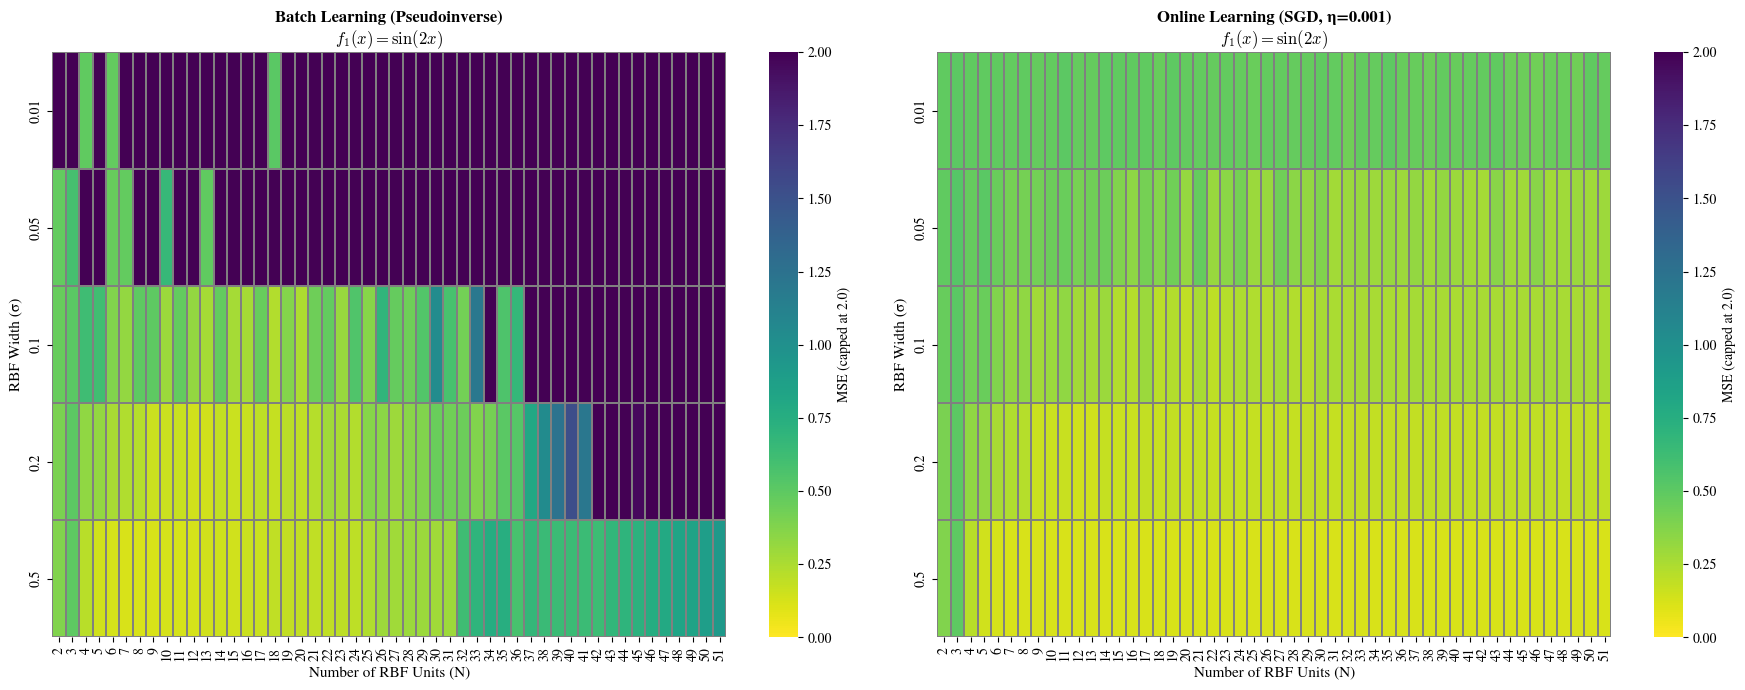

Plotting heatmap for f₂(x) = sgn(sin(2x))...


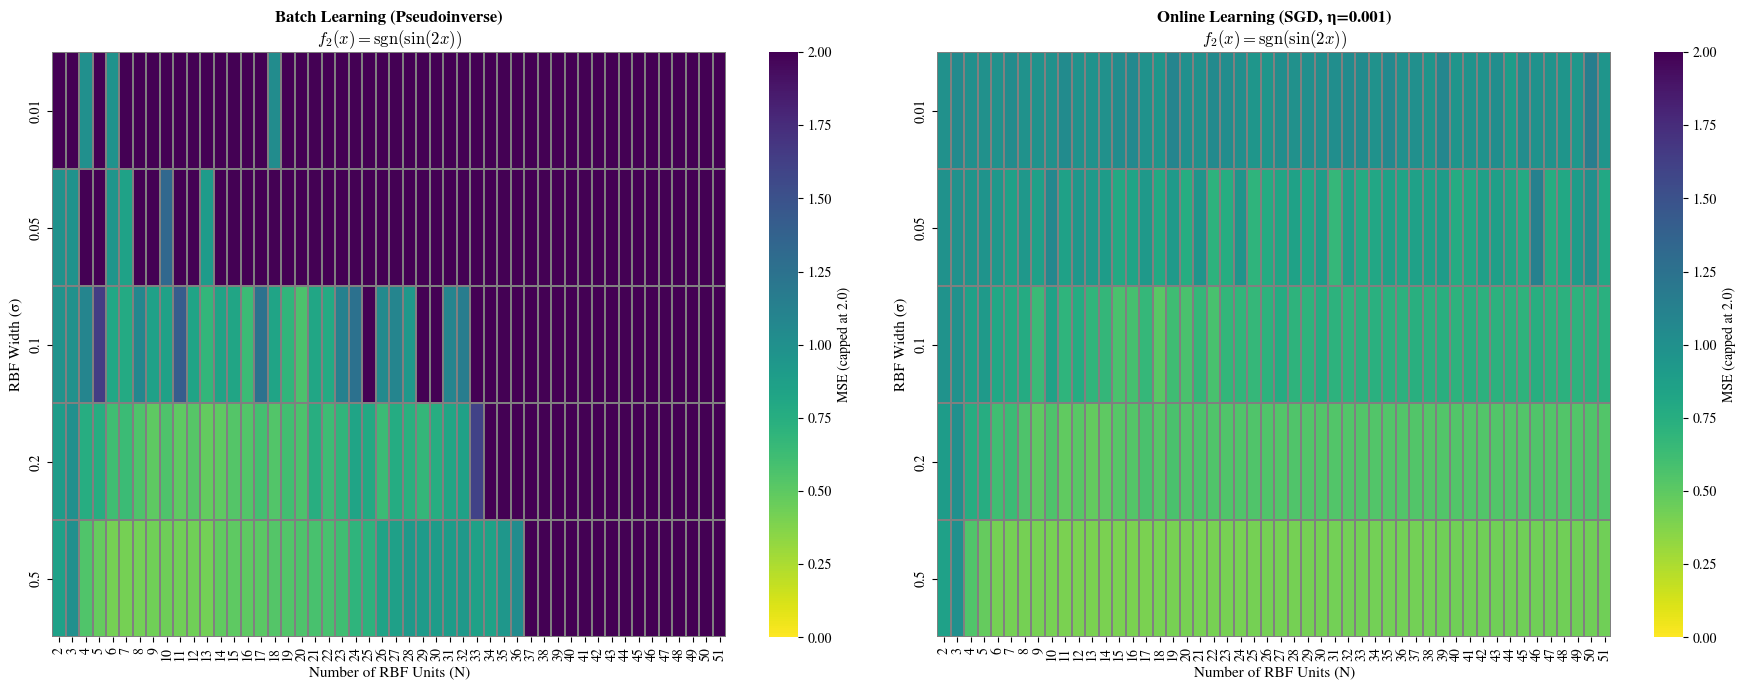


STEP 8: DETAILED COMPARISON - SAMPLE CONFIGURATIONS

f₁(x) = sin(2x):
  N      σ    Batch MSE   Online MSE   Difference     Winner
------------------------------------------------------------
  5   0.10     0.614641     0.459453    +0.155188     Online
 10   0.10     0.299221     0.297561    +0.001661     Online
 20   0.10     0.243778     0.189386    +0.054393     Online
 30   0.20     0.454303     0.179961    +0.274342     Online

f₂(x) = sgn(sin(2x)):
  N      σ    Batch MSE   Online MSE   Difference     Winner
------------------------------------------------------------
  5   0.10     1.641908     0.915077    +0.726832     Online
 10   0.10     0.854182     0.850879    +0.003303     Online
 20   0.10     0.570300     0.571331    -0.001032      Batch
 30   0.20     0.756254     0.546541    +0.209712     Online


In [5]:
# Generate clean training and test sets
train_set = np.arange(0, 2 * np.pi + 0.1, step=0.1)
test_set = np.arange(0.05, 2 * np.pi + 0.1, step=0.1)

# Define target functions
f2 = lambda x: np.where(np.sin(2*x) >= 0, 1.0, -1.0)

f_1_train = np.sin(2 * train_set)
f_2_train = f2(train_set)
f_1_test = np.sin(2 * test_set)
f_2_test = f2(test_set)

var_noise = 0.1
std_noise = np.sqrt(var_noise)

X_train_noisy = train_set.reshape(-1, 1) + np.random.normal(0, std_noise, train_set.reshape(-1, 1).shape)
X_test_noisy = test_set.reshape(-1, 1) + np.random.normal(0, std_noise, test_set.reshape(-1, 1).shape)

f1_train_noisy = f_1_train + np.random.normal(0, std_noise, f_1_train.shape)
f2_train_noisy = f_2_train + np.random.normal(0, std_noise, f_2_train.shape)

N_train = len(X_train_noisy)
N_test = len(X_test_noisy)


RBF_layer_sizes = np.arange(2, 52, step=1)  # 2 to 51 units
domain_range = 2 * np.pi
STDs = np.array([0.01, 0.05, 0.1, 0.2, 0.5])  # RBF widths

# Online learning hyperparameters
EPOCHS = 4000
lr = 0.001


SUMMARY = {
    "batch": {"f1": {}, "f2": {}},
    "online": {"f1": {}, "f2": {}}
}

# Main loop
for rbf_idx, RBF_size in enumerate(RBF_layer_sizes):
    # Progress indicator
    if rbf_idx % 10 == 0:
        print(f"[{rbf_idx+1:2d}/{len(RBF_layer_sizes)}] Processing RBF size {RBF_size}")
    
    # Place RBF centers uniformly across domain
    step_size = domain_range / (RBF_size + 1)
    centers = np.array([[i * step_size for i in range(1, RBF_size + 1)]])
    
    for std in STDs:
        # Compute design matrices
        PHI_train = compute_phi(X_train_noisy, centers, std)
        PHI_test = compute_phi(X_test_noisy, centers, std)
        
        
        W1_batch = (np.linalg.pinv(PHI_train) @ f1_train_noisy.reshape(-1, 1)).T
        W2_batch = (np.linalg.pinv(PHI_train) @ f2_train_noisy.reshape(-1, 1)).T
        
        # Evaluate on clean test data
        pred_f1_batch = (W1_batch @ PHI_test.T).T
        pred_f2_batch = (W2_batch @ PHI_test.T).T
        
        err_batch_f1 = np.mean((pred_f1_batch - f_1_test.reshape(-1, 1)) ** 2)
        err_batch_f2 = np.mean((pred_f2_batch - f_2_test.reshape(-1, 1)) ** 2)
        
        # Handle anomalies (shouldn't happen with proper pseudoinverse)
        if np.isnan(err_batch_f1) or np.isinf(err_batch_f1):
            err_batch_f1 = baseline_f1 * 10
        if np.isnan(err_batch_f2) or np.isinf(err_batch_f2):
            err_batch_f2 = baseline_f2 * 10
        
        
        W1_online = np.random.randn(1, RBF_size) * 0.1
        W2_online = np.random.randn(1, RBF_size) * 0.1
        
        # Training loop
        for epoch in range(EPOCHS):
            # Shuffle data each epoch
            indices = np.random.permutation(N_train)
            PHI_shuffled = PHI_train[indices, :]
            y1_shuffled = f1_train_noisy[indices]
            y2_shuffled = f2_train_noisy[indices]
            
            # Update weights for each sample (stochastic gradient descent)
            for i in range(N_train):
                phi_i = PHI_shuffled[i:i+1, :]  # Shape (1, RBF_size)
                
                # Forward pass: predictions
                pred_1 = (W1_online @ phi_i.T).item()
                pred_2 = (W2_online @ phi_i.T).item()
                
                # Errors
                e1 = y1_shuffled[i] - pred_1
                e2 = y2_shuffled[i] - pred_2
                
                # Delta rule: ΔW = η * e * φ(x)
                W1_online += lr * e1 * phi_i
                W2_online += lr * e2 * phi_i
        
        # Evaluate on clean test data
        pred_f1_online = (W1_online @ PHI_test.T).T
        pred_f2_online = (W2_online @ PHI_test.T).T
        
        err_online_f1 = np.mean((pred_f1_online - f_1_test.reshape(-1, 1)) ** 2)
        err_online_f2 = np.mean((pred_f2_online - f_2_test.reshape(-1, 1)) ** 2)
        
        # Handle anomalies
        if np.isnan(err_online_f1) or np.isinf(err_online_f1):
            err_online_f1 = baseline_f1 * 10
        if np.isnan(err_online_f2) or np.isinf(err_online_f2):
            err_online_f2 = baseline_f2 * 10
        

        SUMMARY["batch"]["f1"][(RBF_size, std)] = err_batch_f1
        SUMMARY["batch"]["f2"][(RBF_size, std)] = err_batch_f2
        SUMMARY["online"]["f1"][(RBF_size, std)] = err_online_f1
        SUMMARY["online"]["f2"][(RBF_size, std)] = err_online_f2
  

print("="*80)
print("STEP 7: GENERATING HEATMAPS")
print("="*80 + "\n")

def plot_heatmaps_with_diagnostics(summary_dict, target_func="f1", max_display_mse=2.0):
    """Plot side-by-side heatmaps comparing batch vs online learning"""
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    for idx, mode in enumerate(["batch", "online"]):
        # Build matrix: rows=STDs, cols=RBF_layer_sizes
        matrix = np.zeros((len(STDs), len(RBF_layer_sizes)))
        
        for i, s in enumerate(STDs):
            for j, r_size in enumerate(RBF_layer_sizes):
                val = summary_dict[mode][target_func][(r_size, s)]
                
                # Handle anomalies
                if np.isnan(val) or np.isinf(val):
                    val = max_display_mse
                else:
                    val = min(val, max_display_mse)
                
                matrix[i, j] = val
        
        # Create heatmap
        sns.heatmap(
            matrix,
            xticklabels=RBF_layer_sizes,
            yticklabels=STDs,
            ax=axes[idx],
            cmap="viridis_r",
            vmin=0.0,
            vmax=max_display_mse,
            cbar_kws={'label': f'MSE (capped at {max_display_mse})'},
            linewidths=0.2,
            linecolor='gray'
        )
        
        mode_label = "Batch Learning (Pseudoinverse)" if mode == "batch" else f"Online Learning (SGD, η={lr})"
        func_label = r"$f_1(x) = \sin(2x)$" if target_func == "f1" else r"$f_2(x) = \text{sgn}(\sin(2x))$"
        
        axes[idx].set_title(
            f"{mode_label}\n{func_label}",
            fontsize=12,
            fontweight="bold"
        )
        axes[idx].set_xlabel("Number of RBF Units (N)", fontsize=11)
        axes[idx].set_ylabel("RBF Width (σ)", fontsize=11)
    
    plt.tight_layout()
    plt.show()

# Plot heatmaps for both functions
print("Plotting heatmap for f₁(x) = sin(2x)...")
plot_heatmaps_with_diagnostics(SUMMARY, target_func="f1", max_display_mse=2.0)

print("Plotting heatmap for f₂(x) = sgn(sin(2x))...")
plot_heatmaps_with_diagnostics(SUMMARY, target_func="f2", max_display_mse=2.0)


print("\n" + "="*80)
print("STEP 8: DETAILED COMPARISON - SAMPLE CONFIGURATIONS")
print("="*80 + "\n")

sample_configs = [
    (5, 0.1),   # Small N, narrow σ
    (10, 0.1),  # Medium N, narrow σ
    (20, 0.1),  # Larger N, narrow σ
    (30, 0.2),  # Large N, medium σ
]

print("f₁(x) = sin(2x):")
print(f"{'N':>3} {'σ':>6} {'Batch MSE':>12} {'Online MSE':>12} {'Difference':>12} {'Winner':>10}")
print("-" * 60)

for rbf_size, sigma in sample_configs:
    if (rbf_size, sigma) in SUMMARY["batch"]["f1"]:
        batch_err = SUMMARY["batch"]["f1"][(rbf_size, sigma)]
        online_err = SUMMARY["online"]["f1"][(rbf_size, sigma)]
        diff = batch_err - online_err
        winner = "Batch" if batch_err < online_err else "Online"
        
        print(f"{rbf_size:3d} {sigma:6.2f} {batch_err:12.6f} {online_err:12.6f} {diff:+12.6f} {winner:>10}")

print()
print("f₂(x) = sgn(sin(2x)):")
print(f"{'N':>3} {'σ':>6} {'Batch MSE':>12} {'Online MSE':>12} {'Difference':>12} {'Winner':>10}")
print("-" * 60)

for rbf_size, sigma in sample_configs:
    if (rbf_size, sigma) in SUMMARY["batch"]["f2"]:
        batch_err = SUMMARY["batch"]["f2"][(rbf_size, sigma)]
        online_err = SUMMARY["online"]["f2"][(rbf_size, sigma)]
        diff = batch_err - online_err
        winner = "Batch" if batch_err < online_err else "Online"
        
        print(f"{rbf_size:3d} {sigma:6.2f} {batch_err:12.6f} {online_err:12.6f} {diff:+12.6f} {winner:>10}")



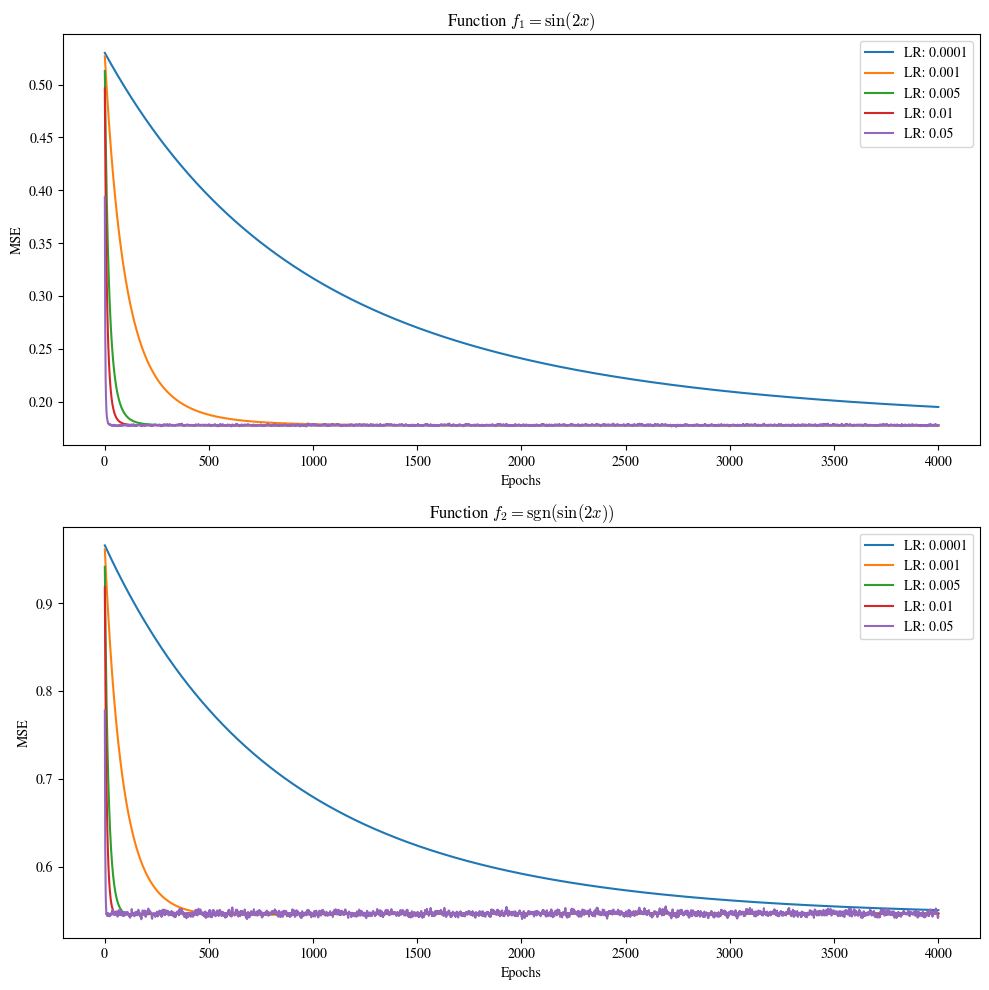

In [6]:
RBF_size = 5
std = 0.4
LRs = [0.0001, 0.001, 0.005, 0.01, 0.05]

history = {
    "f1": {},
    "f2": {}
}

for lr in LRs:
    step_size = domain_range / (RBF_size + 1)
    centers = np.array([[i * step_size for i in range(1, RBF_size + 1)]])
    PHI_train = compute_phi(X_train_noisy, centers, std)
    PHI_test = compute_phi(X_test_noisy, centers, std)
    history["f1"][f"{lr}"] = []
    history["f2"][f"{lr}"] = []

    np.random.seed(13)
    W1_online = np.random.randn(1, RBF_size) * 0.1
    W2_online = np.random.randn(1, RBF_size) * 0.1

    for epoch in range(EPOCHS):
        indices = np.random.permutation(N_train)
        PHI_shuffled = PHI_train[indices, :]
        y1_shuffled = f1_train_noisy[indices]
        y2_shuffled = f2_train_noisy[indices]

        for i in range(N_train):
            phi_i = PHI_shuffled[i:i+1, :]  # Shape (1, RBF_size)
            
            pred_1 = (W1_online @ phi_i.T).item()
            pred_2 = (W2_online @ phi_i.T).item()

            e1 = y1_shuffled[i] - pred_1
            e2 = y2_shuffled[i] - pred_2

            W1_online += lr * e1 * phi_i
            W2_online += lr * e2 * phi_i

        err_online_f1 = np.mean(((W1_online @ PHI_test.T).T - f_1_test.reshape(-1, 1)) ** 2)
        err_online_f2 = np.mean(((W2_online @ PHI_test.T).T - f_2_test.reshape(-1, 1)) ** 2)
        history["f1"][f"{lr}"].append(err_online_f1)
        history["f2"][f"{lr}"].append(err_online_f2)

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

for function, LRs_history in history.items():
    if function == "f1":
        for lr, errors in LRs_history.items():
            axes[0].plot(range(1, EPOCHS + 1), errors, label=f"LR: {lr}")
        axes[0].set_title(r"Function $f_1=\sin(2x)$")
        axes[0].set_xlabel("Epochs")
        axes[0].set_ylabel("MSE")
        axes[0].legend()
    else:
        for lr, errors in LRs_history.items():
            axes[1].plot(range(1, EPOCHS + 1), errors, label=f"LR: {lr}")
        axes[1].set_title(r"Function $f_2=\text{sgn}(\sin(2x))$")
        axes[1].set_xlabel("Epochs")
        axes[1].set_ylabel("MSE")
        axes[1].legend()

plt.tight_layout()
plt.show()

In [7]:
RBF_size = 5
std = 0.4
lr = 0.05

repeat = 100

summary = {
    "uniformly": {
        "f1": [],
        "f2": []
    },
    "randomly": {
        "f1": [],
        "f2": []
    }
}

for i in range(repeat):

    # Uniformly distribute
    step_size = domain_range / (RBF_size + 1)
    centers_u = np.array([[i * step_size for i in range(1, RBF_size + 1)]])
    PHI_train_u = compute_phi(X_train_noisy, centers_u, std)
    PHI_test_u = compute_phi(X_test_noisy, centers_u, std)

    # Randomly distribute
    centers_r = np.random.random(size=(1, RBF_size)) * domain_range
    PHI_train_r = compute_phi(X_train_noisy, centers_r, std)
    PHI_test_r = compute_phi(X_test_noisy, centers_r, std)

    np.random.seed(13 + i)
    W1_online = np.random.randn(1, RBF_size) * 0.1
    W2_online = np.random.randn(1, RBF_size) * 0.1

    W1_r = W1_online.copy()
    W1_u = W1_online.copy()
    W2_r = W2_online.copy()
    W2_u = W2_online.copy()

    for epoch in range(EPOCHS):
        indices = np.random.permutation(N_train)
        PHI_shuffled_u = PHI_train_u[indices, :]
        PHI_shuffled_r = PHI_train_r[indices, :]
        y1_shuffled = f1_train_noisy[indices]
        y2_shuffled = f2_train_noisy[indices]

        for i in range(N_train):
            phi_i_u = PHI_shuffled_u[i:i+1, :] 
            phi_i_r = PHI_shuffled_r[i:i+1, :] 
            
            pred_1_u = (W1_u @ phi_i_u.T).item()
            pred_2_u = (W2_u @ phi_i_u.T).item()

            pred_1_r = (W1_r @ phi_i_r.T).item()
            pred_2_r = (W2_r @ phi_i_r.T).item()

            e1_u = y1_shuffled[i] - pred_1_u
            e2_u = y2_shuffled[i] - pred_2_u

            e1_r = y1_shuffled[i] - pred_1_r
            e2_r = y2_shuffled[i] - pred_2_r

            W1_u += lr * e1_u * phi_i_u
            W2_u += lr * e2_u * phi_i_u

            W1_r += lr * e1_r * phi_i_r
            W2_r += lr * e2_r * phi_i_r

    err_f1_u = np.mean(((W1_u @ PHI_test_u.T).T - f_1_test.reshape(-1, 1)) ** 2)
    err_f2_u = np.mean(((W2_u @ PHI_test_u.T).T - f_2_test.reshape(-1, 1)) ** 2)
    err_f1_r = np.mean(((W1_r @ PHI_test_r.T).T - f_1_test.reshape(-1, 1)) ** 2)
    err_f2_r = np.mean(((W2_r @ PHI_test_r.T).T - f_2_test.reshape(-1, 1)) ** 2)

    summary["uniformly"]["f1"].append(err_f1_u)
    summary["uniformly"]["f2"].append(err_f2_u)
    summary["randomly"]["f1"].append(err_f1_r)
    summary["randomly"]["f2"].append(err_f2_r)

for mode, fucn_hist in summary.items():
    print(f"Distributed {mode}:")
    for func, err_hist in fucn_hist.items():
        print(f"   {func} MSE: {np.mean(err_hist)} +/- {np.std(err_hist)}")
    print()


Distributed uniformly:
   f1 MSE: 0.17835298919180118 +/- 0.0004365917618567401
   f2 MSE: 0.5473653794203347 +/- 0.0022592385258806765

Distributed randomly:
   f1 MSE: 0.26738505688638137 +/- 0.051814022727057554
   f2 MSE: 0.6423648712195184 +/- 0.08756207661051679



<>:103: SyntaxWarning: invalid escape sequence '\s'
<>:126: SyntaxWarning: invalid escape sequence '\s'
<>:103: SyntaxWarning: invalid escape sequence '\s'
<>:126: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_61/1246751822.py:103: SyntaxWarning: invalid escape sequence '\s'
  label=f"Noise Floor ($\sigma^2={noise_variance}$)",
/tmp/ipykernel_61/1246751822.py:126: SyntaxWarning: invalid escape sequence '\s'
  label=f"Noise Floor ($\sigma^2={noise_variance}$)",


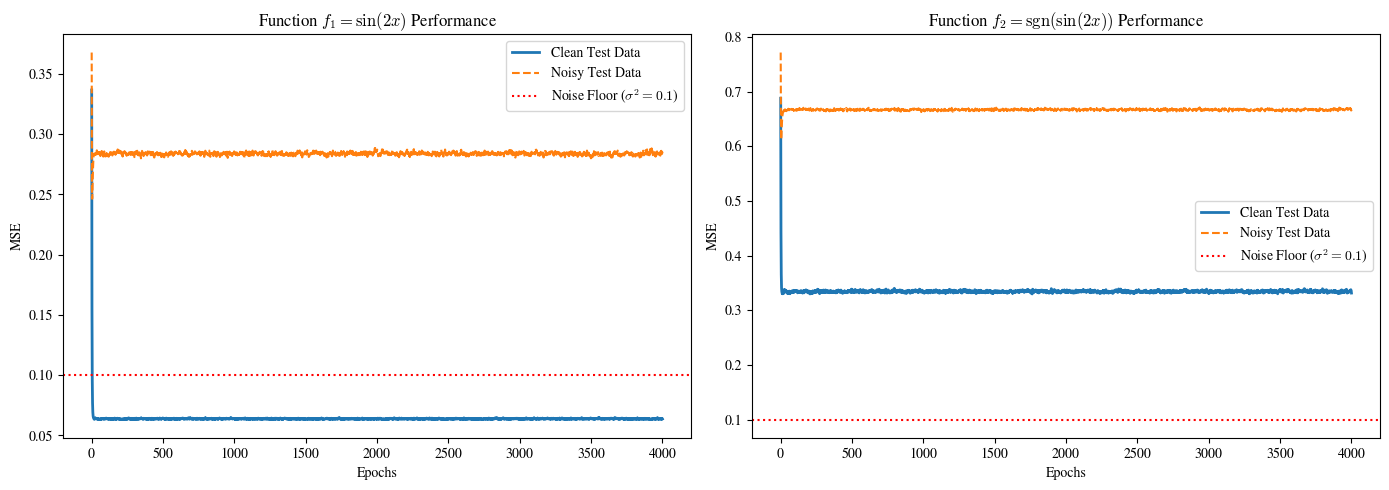

In [8]:
RBF_size = 5
std = 0.4
lr = 0.05
noise_variance = 0.1
std_noise = np.sqrt(noise_variance)

# Generate Clean and Noisy Datasets
X_train_clean = train_set.reshape(-1, 1)
X_test_clean = test_set.reshape(-1, 1)

f1_train_clean = f_1_train.reshape(-1, 1)
f2_train_clean = f_2_train.reshape(-1, 1)
f1_test_clean = f_1_test.reshape(-1, 1)
f2_test_clean = f_2_test.reshape(-1, 1)

np.random.seed(11)
X_train_noisy = X_train_clean + np.random.normal(
    0, std_noise, X_train_clean.shape
)
X_test_noisy = X_test_clean + np.random.normal(0, std_noise, X_test_clean.shape)

f1_train_noisy = f1_train_clean + np.random.normal(
    0, std_noise, f1_train_clean.shape
)
f2_train_noisy = f2_train_clean + np.random.normal(
    0, std_noise, f2_train_clean.shape
)

step_size = domain_range / (RBF_size + 1)
centers = np.array([[i * step_size for i in range(1, RBF_size + 1)]])

PHI_train_noisy = compute_phi(X_train_noisy, centers, std)
PHI_test_noisy = compute_phi(X_test_noisy, centers, std)
PHI_test_clean = compute_phi(X_test_clean, centers, std)

np.random.seed(13)
W1_online = np.random.randn(1, RBF_size) * 0.1
W2_online = np.random.randn(1, RBF_size) * 0.1

history = {
    "f1": {"clean_test_mse": [], "noisy_test_mse": []},
    "f2": {"clean_test_mse": [], "noisy_test_mse": []},
}

N_train = X_train_noisy.shape[0]

for epoch in range(EPOCHS):
  indices = np.random.permutation(N_train)
  PHI_shuffled = PHI_train_noisy[indices, :]
  y1_shuffled = f1_train_noisy[indices]
  y2_shuffled = f2_train_noisy[indices]

  for sample_idx in range(N_train):
    phi_i = PHI_shuffled[sample_idx : sample_idx + 1, :]

    pred_1 = (W1_online @ phi_i.T).item()
    pred_2 = (W2_online @ phi_i.T).item()

    e1 = y1_shuffled[sample_idx] - pred_1
    e2 = y2_shuffled[sample_idx] - pred_2

    W1_online += lr * e1 * phi_i
    W2_online += lr * e2 * phi_i

  err_f1_noisy = np.mean(
      ((W1_online @ PHI_test_noisy.T).T - f1_test_clean) ** 2
  )
  err_f2_noisy = np.mean(
      ((W2_online @ PHI_test_noisy.T).T - f2_test_clean) ** 2
  )

  err_f1_clean = np.mean(
      ((W1_online @ PHI_test_clean.T).T - f1_test_clean) ** 2
  )
  err_f2_clean = np.mean(
      ((W2_online @ PHI_test_clean.T).T - f2_test_clean) ** 2
  )

  history["f1"]["noisy_test_mse"].append(err_f1_noisy)
  history["f1"]["clean_test_mse"].append(err_f1_clean)
  history["f2"]["noisy_test_mse"].append(err_f2_noisy)
  history["f2"]["clean_test_mse"].append(err_f2_clean)

# Plotting Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    range(1, EPOCHS + 1),
    history["f1"]["clean_test_mse"],
    label="Clean Test Data",
    linewidth=2,
)
axes[0].plot(
    range(1, EPOCHS + 1),
    history["f1"]["noisy_test_mse"],
    label="Noisy Test Data",
    linestyle="--",
)
axes[0].axhline(
    y=noise_variance,
    color="r",
    linestyle=":",
    label=f"Noise Floor ($\sigma^2={noise_variance}$)",
)
axes[0].set_title(r"Function $f_1 = \sin(2x)$ Performance")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("MSE")
axes[0].legend()

axes[1].plot(
    range(1, EPOCHS + 1),
    history["f2"]["clean_test_mse"],
    label="Clean Test Data",
    linewidth=2,
)
axes[1].plot(
    range(1, EPOCHS + 1),
    history["f2"]["noisy_test_mse"],
    label="Noisy Test Data",
    linestyle="--",
)
axes[1].axhline(
    y=noise_variance,
    color="r",
    linestyle=":",
    label=f"Noise Floor ($\sigma^2={noise_variance}$)",
)
axes[1].set_title(r"Function $f_2 = \text{sgn}(\sin(2x))$ Performance")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("MSE")
axes[1].legend()

plt.tight_layout()
plt.show()

RBF vs MLP — NOISY DATA BENCHMARK
Number of hidden/RBF units: 5

Function f1 = sin(2x)
----------------------------------------
RBF test MSE:       0.072013
MLP test MSE:       0.425135
RBF training time:  0.028812 s
MLP training time:  0.074915 s

Function f2 = sign(sin(2x))
----------------------------------------
RBF test MSE:       0.320864
MLP test MSE:       0.814753
RBF training time:  0.028812 s
MLP training time:  0.074482 s


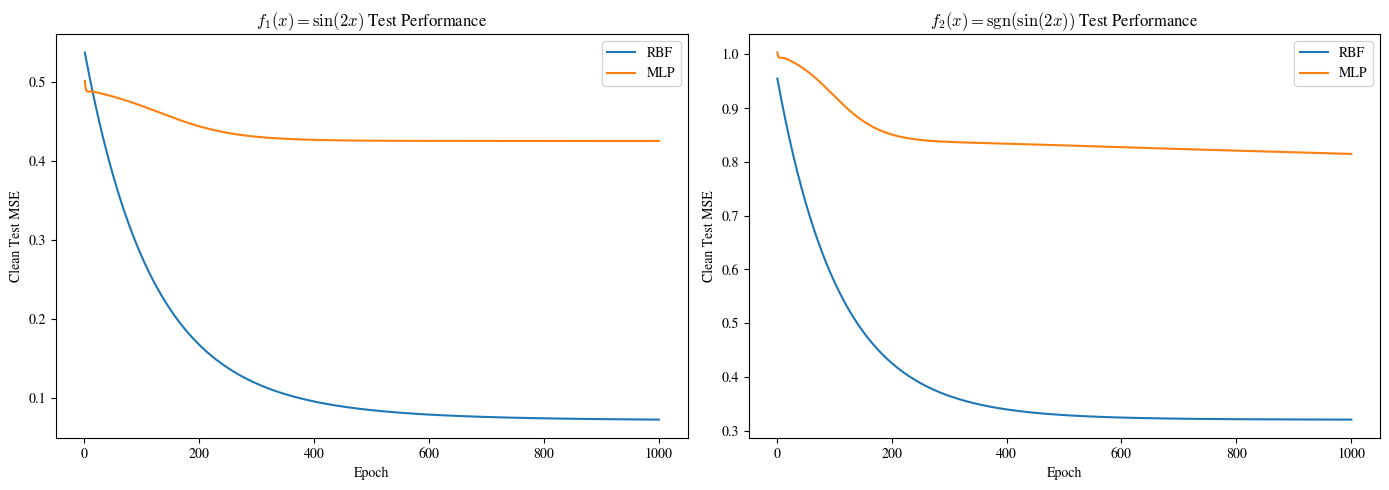

In [9]:
import time
import matplotlib.pyplot as plt
import numpy as np

# Parameters
RBF_size = 5
RBF_std = 0.4
RBF_lr = 0.05
MLP_lr = 0.05

EPOCHS = 1000
hidden_units = RBF_size

noise_variance = 0.1
noise_std = np.sqrt(noise_variance)

np.random.seed(13)

# Data Reshaping
X_train = train_set.reshape(-1, 1)
X_test = test_set.reshape(-1, 1)

f1_train = f_1_train.reshape(-1, 1)
f1_test = f_1_test.reshape(-1, 1)

f2_train = f_2_train.reshape(-1, 1)
f2_test = f_2_test.reshape(-1, 1)

# Corrupt features & labels with zero-mean Gaussian noise (var = 0.1)
X_train_noisy = X_train + np.random.normal(0, noise_std, X_train.shape)
X_test_noisy = X_test + np.random.normal(0, noise_std, X_test.shape)

f1_train_noisy = f1_train + np.random.normal(0, noise_std, f1_train.shape)
f2_train_noisy = f2_train + np.random.normal(0, noise_std, f2_train.shape)

N_train = X_train.shape[0]


def compute_phi(X, centers, std):
  return np.exp(-((X - centers) ** 2) / (2 * std**2))


step_size = domain_range / (RBF_size + 1)
centers = np.array([[i * step_size for i in range(1, RBF_size + 1)]])

PHI_train = compute_phi(X_train_noisy, centers, RBF_std)
PHI_test_clean = compute_phi(X_test, centers, RBF_std)

# --- 1. RBF NETWORK TRAINING (Normalized Batch Gradient Descent) ---
np.random.seed(13)
W1_rbf = np.random.randn(1, RBF_size) * 0.1
W2_rbf = np.random.randn(1, RBF_size) * 0.1

rbf_f1_history = []
rbf_f2_history = []

start_time = time.perf_counter()

for epoch in range(EPOCHS):
  # Forward pass on training set (Shape: 1, N)
  pred_f1 = W1_rbf @ PHI_train.T
  pred_f2 = W2_rbf @ PHI_train.T

  # Errors (Shape: 1, N)
  error_f1 = f1_train_noisy.T - pred_f1
  error_f2 = f2_train_noisy.T - pred_f2

  # Normalized Batch Delta-Rule Update
  W1_rbf += (RBF_lr / N_train) * (error_f1 @ PHI_train)
  W2_rbf += (RBF_lr / N_train) * (error_f2 @ PHI_train)

  # Evaluate against CLEAN test targets
  test_pred_f1 = W1_rbf @ PHI_test_clean.T
  test_pred_f2 = W2_rbf @ PHI_test_clean.T

  test_mse_f1 = np.mean((test_pred_f1.T - f1_test) ** 2)
  test_mse_f2 = np.mean((test_pred_f2.T - f2_test) ** 2)

  rbf_f1_history.append(test_mse_f1)
  rbf_f2_history.append(test_mse_f2)

rbf_training_time = time.perf_counter() - start_time
rbf_f1_mse = rbf_f1_history[-1]
rbf_f2_mse = rbf_f2_history[-1]


# --- 2. MLP TRAINING (Backpropagation) ---
def sigmoid(x):
  return 1 / (1 + np.exp(-x))


def sigmoid_derivative(x):
  s = sigmoid(x)
  return s * (1 - s)


def initialize_mlp(n_hidden):
  W1 = np.random.randn(1, n_hidden) * 0.1
  b1 = np.zeros((1, n_hidden))
  W2 = np.random.randn(n_hidden, 1) * 0.1
  b2 = np.zeros((1, 1))
  return W1, b1, W2, b2


def train_mlp_batch(
    X, y, X_test_clean, y_test_clean, hidden_units, lr, epochs
):
  np.random.seed(13)
  W1, b1, W2, b2 = initialize_mlp(hidden_units)

  train_history = []
  test_history = []

  start_time = time.perf_counter()

  for epoch in range(epochs):
    # Forward Pass
    Z1 = X @ W1 + b1
    H = sigmoid(Z1)
    output = H @ W2 + b2

    # Loss & Gradient Computation
    error = output - y
    d_output = 2 * error / X.shape[0]

    dW2 = H.T @ d_output
    db2 = np.sum(d_output, axis=0, keepdims=True)

    dH = d_output @ W2.T
    dZ1 = dH * sigmoid_derivative(Z1)

    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    # Gradient Step
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

    # Training MSE
    train_mse = np.mean((output - y) ** 2)

    # Test MSE against CLEAN ground truth
    H_test = sigmoid(X_test_clean @ W1 + b1)
    test_output = H_test @ W2 + b2
    test_mse = np.mean((test_output - y_test_clean) ** 2)

    train_history.append(train_mse)
    test_history.append(test_mse)

  training_time = time.perf_counter() - start_time
  return (
      W1,
      b1,
      W2,
      b2,
      train_history,
      test_history,
      training_time,
  )


# Train MLP on f1
(
    W1_f1,
    b1_f1,
    W2_f1,
    b2_f1,
    mlp_f1_tr,
    mlp_f1_test_history,
    mlp_f1_time,
) = train_mlp_batch(
    X_train_noisy,
    f1_train_noisy,
    X_test,
    f1_test,
    hidden_units,
    MLP_lr,
    EPOCHS,
)
mlp_f1_mse = mlp_f1_test_history[-1]

# Train MLP on f2
(
    W1_f2,
    b1_f2,
    W2_f2,
    b2_f2,
    mlp_f2_tr,
    mlp_f2_test_history,
    mlp_f2_time,
) = train_mlp_batch(
    X_train_noisy,
    f2_train_noisy,
    X_test,
    f2_test,
    hidden_units,
    MLP_lr,
    EPOCHS,
)
mlp_f2_mse = mlp_f2_test_history[-1]

# Display Metrics
print("=" * 60)
print("RBF vs MLP — NOISY DATA BENCHMARK")
print("=" * 60)
print(f"Number of hidden/RBF units: {RBF_size}")
print(f"\nFunction f1 = sin(2x)")
print("-" * 40)
print(f"RBF test MSE:       {rbf_f1_mse:.6f}")
print(f"MLP test MSE:       {mlp_f1_mse:.6f}")
print(f"RBF training time:  {rbf_training_time:.6f} s")
print(f"MLP training time:  {mlp_f1_time:.6f} s")

print(f"\nFunction f2 = sign(sin(2x))")
print("-" * 40)
print(f"RBF test MSE:       {rbf_f2_mse:.6f}")
print(f"MLP test MSE:       {mlp_f2_mse:.6f}")
print(f"RBF training time:  {rbf_training_time:.6f} s")
print(f"MLP training time:  {mlp_f2_time:.6f} s")

# Plot Learning Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, EPOCHS + 1), rbf_f1_history, label="RBF")
axes[0].plot(range(1, EPOCHS + 1), mlp_f1_test_history, label="MLP")
axes[0].set_title(r"$f_1(x)=\sin(2x)$ Test Performance")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Clean Test MSE")
axes[0].legend()

axes[1].plot(range(1, EPOCHS + 1), rbf_f2_history, label="RBF")
axes[1].plot(range(1, EPOCHS + 1), mlp_f2_test_history, label="MLP")
axes[1].set_title(r"$f_2(x)=\operatorname{sgn}(\sin(2x))$ Test Performance")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Clean Test MSE")
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.3 Competitive learning for RBF unit placement
#### (a) Helper functions

In [30]:
# 3.3 Competitive learning (CL) to place the RBF units - helper functions

def rbf_phi(X, centers, widths):
    # Gaussian RBF activations, X: (N, d), centers: (M, d), widths: (M,)
    sq_dist = ((X[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
    return np.exp(-sq_dist / (2 * widths ** 2))

def closest_center(X, centers):
    sq_dist = ((X[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
    return np.argmin(sq_dist, axis=1)

def competitive_learning(X, n_units, epochs=50, eta=0.1, leak=0.0, init_centers=None, seed=0):
    # Vanilla CL: only the winner moves (leak=0).
    # Leaky CL: during the first half of training the losers also move towards x with a
    # small step (leak > 0), which pulls dead units into the data. Second half is vanilla.
    rng = np.random.default_rng(seed)
    if init_centers is None:
        centers = X[rng.choice(len(X), n_units, replace=False)].astype(float)
    else:
        centers = init_centers.copy()
    history = [centers.copy()]
    for epoch in range(epochs):
        for i in rng.permutation(len(X)):
            x = X[i]
            winner = np.argmin(((centers - x) ** 2).sum(axis=1))
            step = np.full(n_units, leak if epoch < epochs // 2 else 0.0)
            step[winner] = eta
            centers += step[:, None] * (x - centers)
        history.append(centers.copy())
    return centers, np.array(history)

def cluster_widths(X, centers, scale=1.0):
    # width of each unit = scale * RMS distance of the points assigned to it
    assign = closest_center(X, centers)
    widths = np.full(len(centers), np.nan)
    for i in range(len(centers)):
        points = X[assign == i]
        if len(points) > 1:
            widths[i] = np.sqrt(((points - centers[i]) ** 2).sum(axis=1).mean())
    widths[np.isnan(widths)] = np.nanmean(widths)   # units with 0-1 points get the average width
    return scale * widths

def count_dead_units(X, centers):
    return len(centers) - len(np.unique(closest_center(X, centers)))

def delta_rule(PHI_train, y_train, PHI_test, y_test, eta=0.05, epochs=300, seed=0):
    # on-line learning of the output weights, data shuffled every epoch
    rng = np.random.default_rng(seed)
    W = rng.normal(0, 0.1, size=(PHI_train.shape[1], y_train.shape[1]))
    test_mse = []
    for epoch in range(epochs):
        for k in rng.permutation(len(PHI_train)):
            error = y_train[k] - PHI_train[k] @ W
            W += eta * np.outer(PHI_train[k], error)
        test_mse.append(np.mean((PHI_test @ W - y_test) ** 2))
    return W, test_mse


#### (b) CL vs. manual vs. random placement of the RBF units

clean, manual: test abs residual = 0.0260 +- 0.0010
clean, random: test abs residual = 0.0860 +- 0.0496
clean, CL: test abs residual = 0.0248 +- 0.0053
noisy, manual: test abs residual = 0.2181 +- 0.0023
noisy, random: test abs residual = 0.2696 +- 0.0449
noisy, CL: test abs residual = 0.2240 +- 0.0054


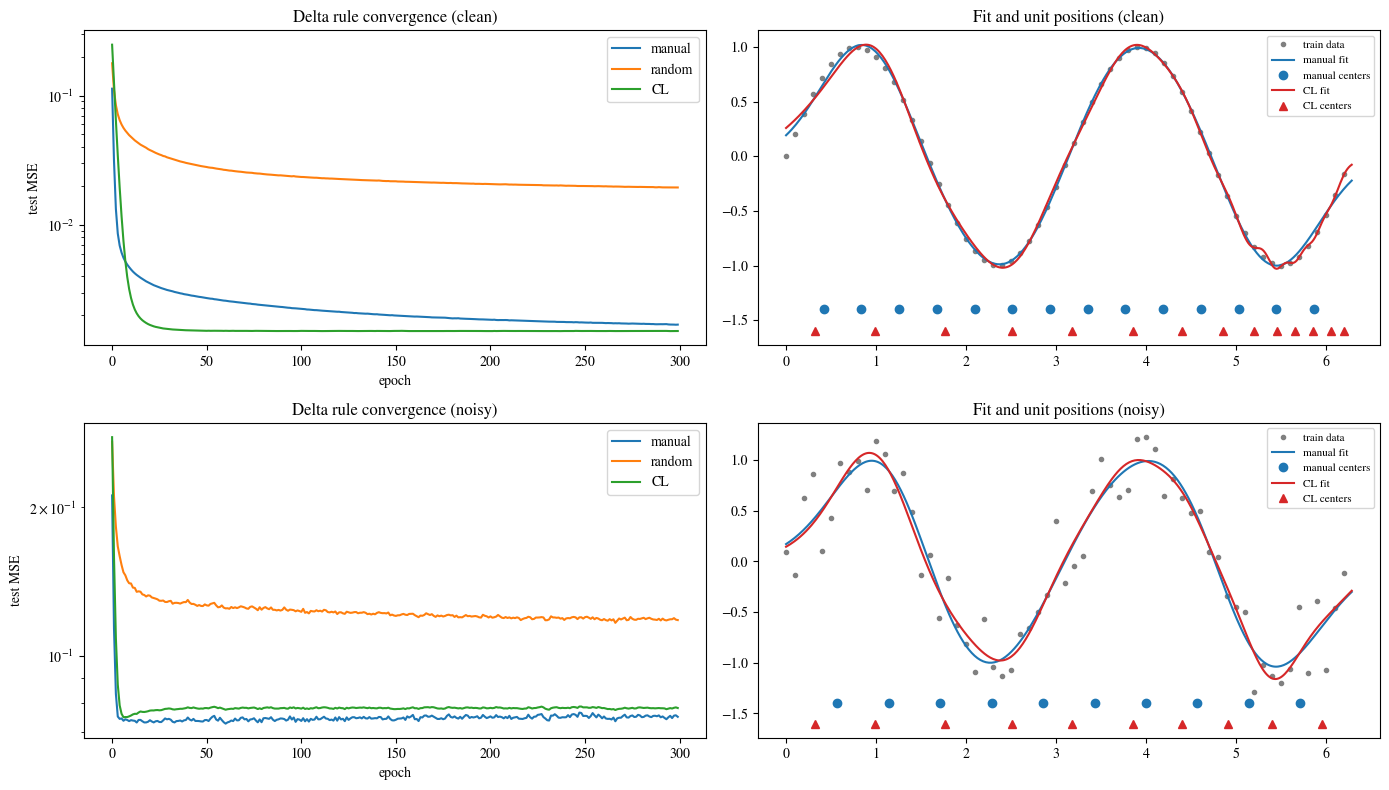

In [34]:
# 3.3 (b) CL vs manual vs random placement of the RBF units, sin(2x) with and without noise
N_UNITS_CLEAN = 14   # TODO: use the best number of units from 3.1
N_UNITS_NOISY = 10   # TODO: use the best number of units from 3.2
MANUAL_WIDTH = 0.5
N_RUNS = 10          # CL and random placement are stochastic, so we average over runs

rng = np.random.default_rng(42)
x_train = np.arange(0, 2 * np.pi, 0.1).reshape(-1, 1)
x_test = np.arange(0.05, 2 * np.pi, 0.1).reshape(-1, 1)
y_train_clean = np.sin(2 * x_train)
y_test_clean = np.sin(2 * x_test)
y_train_noisy = y_train_clean + rng.normal(0, np.sqrt(0.1), y_train_clean.shape)
y_test_noisy = y_test_clean + rng.normal(0, np.sqrt(0.1), y_test_clean.shape)

def place_units(method, n_units, seed):
    if method == "manual":   # evenly spaced over [0, 2pi]
        centers = np.linspace(0, 2 * np.pi, n_units + 2)[1:-1].reshape(-1, 1)
        return centers, np.full(n_units, MANUAL_WIDTH)
    if method == "random":
        centers = np.random.default_rng(seed).uniform(0, 2 * np.pi, (n_units, 1))
        return centers, np.full(n_units, MANUAL_WIDTH)
    if method == "CL":
        centers, _ = competitive_learning(x_train, n_units, seed=seed)
        return centers, cluster_widths(x_train, centers, scale=2.0)

setups = {"clean": (N_UNITS_CLEAN, y_train_clean, y_test_clean),
          "noisy": (N_UNITS_NOISY, y_train_noisy, y_test_noisy)}
curves, models = {}, {}
for setup, (n_units, y_train, y_test) in setups.items():
    for method in ["manual", "random", "CL"]:
        errors, runs_mse = [], []
        for run in range(N_RUNS):
            centers, widths = place_units(method, n_units, seed=run)
            PHI_train = rbf_phi(x_train, centers, widths)
            PHI_test = rbf_phi(x_test, centers, widths)
            W, test_mse = delta_rule(PHI_train, y_train, PHI_test, y_test, seed=run)
            errors.append(np.mean(np.abs(PHI_test @ W - y_test)))
            runs_mse.append(test_mse)
        curves[setup, method] = np.mean(runs_mse, axis=0)
        models[setup, method] = (centers, widths, W)
        print(f"{setup}, {method}: test abs residual = {np.mean(errors):.4f} +- {np.std(errors):.4f}")

x_plot = np.linspace(0, 2 * np.pi, 400).reshape(-1, 1)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for row, (setup, (n_units, y_train, y_test)) in enumerate(setups.items()):
    for method in ["manual", "random", "CL"]:
        axes[row, 0].semilogy(curves[setup, method], label=method)
    axes[row, 0].set_title(f"Delta rule convergence ({setup})")
    axes[row, 0].set_xlabel("epoch")
    axes[row, 0].set_ylabel("test MSE")
    axes[row, 0].legend()

    axes[row, 1].plot(x_train, y_train, ".", color="gray", label="train data")
    for method, marker, color, y_level in [("manual", "o", "tab:blue", -1.4), ("CL", "^", "tab:red", -1.6)]:
        centers, widths, W = models[setup, method]
        axes[row, 1].plot(x_plot, rbf_phi(x_plot, centers, widths) @ W, color=color, label=f"{method} fit")
        axes[row, 1].plot(centers, np.full(len(centers), y_level), marker, color=color, label=f"{method} centers")
    axes[row, 1].set_title(f"Fit and unit positions ({setup})")
    axes[row, 1].legend(fontsize=8)
plt.tight_layout()
plt.savefig("imgs/lab2_331.png", dpi=200, bbox_inches="tight")
plt.show()


#### (c) Dead units: vanilla CL vs. leaky CL

vanilla: 6 dead units, test abs residual = 0.1389
leaky: 0 dead units, test abs residual = 0.0386


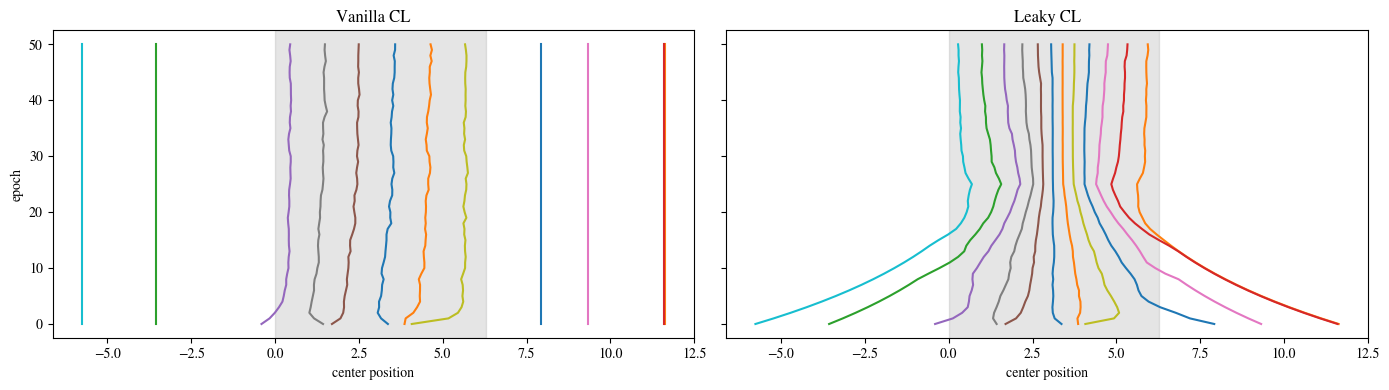

In [35]:
# 3.3 (c) Dead units: vanilla CL vs leaky CL
# To get dead units we initialise the centers in a range much wider than the data
n_units = 12
init_centers = np.random.default_rng(1).uniform(-2 * np.pi, 4 * np.pi, (n_units, 1))

centers_vanilla, history_vanilla = competitive_learning(x_train, n_units, init_centers=init_centers)
centers_leaky, history_leaky = competitive_learning(x_train, n_units, leak=0.001, init_centers=init_centers)

for name, centers in [("vanilla", centers_vanilla), ("leaky", centers_leaky)]:
    widths = cluster_widths(x_train, centers, scale=2.0)
    W, _ = delta_rule(rbf_phi(x_train, centers, widths), y_train_clean,
                      rbf_phi(x_test, centers, widths), y_test_clean)
    error = np.mean(np.abs(rbf_phi(x_test, centers, widths) @ W - y_test_clean))
    print(f"{name}: {count_dead_units(x_train, centers)} dead units, test abs residual = {error:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, history, title in [(axes[0], history_vanilla, "Vanilla CL"), (axes[1], history_leaky, "Leaky CL")]:
    ax.plot(history[:, :, 0], np.arange(len(history)))
    ax.axvspan(0, 2 * np.pi, color="gray", alpha=0.2)   # range of the data
    ax.set_title(title)
    ax.set_xlabel("center position")
axes[0].set_ylabel("epoch")
plt.tight_layout()
plt.savefig("imgs/lab2_332.png", dpi=200, bbox_inches="tight")   
plt.show()


#### (d) 2D RBF network on the ballistic data

units=6, width scale=1.5: test MSE = 0.01617, dead units = 0
units=8, width scale=1.5: test MSE = 0.01792, dead units = 0
units=10, width scale=1.5: test MSE = 0.01514, dead units = 0
units=12, width scale=1.5: test MSE = 0.01332, dead units = 0
units=15, width scale=1.5: test MSE = 0.01450, dead units = 0
units=20, width scale=1.5: test MSE = 0.01448, dead units = 0
units=25, width scale=1.5: test MSE = 0.01921, dead units = 1
units=6, width scale=2.5: test MSE = 0.00926, dead units = 0
units=8, width scale=2.5: test MSE = 0.00605, dead units = 0
units=10, width scale=2.5: test MSE = 0.00392, dead units = 0
units=12, width scale=2.5: test MSE = 0.00274, dead units = 0
units=15, width scale=2.5: test MSE = 0.00379, dead units = 0
units=20, width scale=2.5: test MSE = 0.00310, dead units = 0
units=25, width scale=2.5: test MSE = 0.00422, dead units = 1
units=6, width scale=3.5: test MSE = 0.00977, dead units = 0
units=8, width scale=3.5: test MSE = 0.00365, dead units = 0
units=10, widt

FileNotFoundError: [Errno 2] No such file or directory: 'imgs/lab2_334.png'

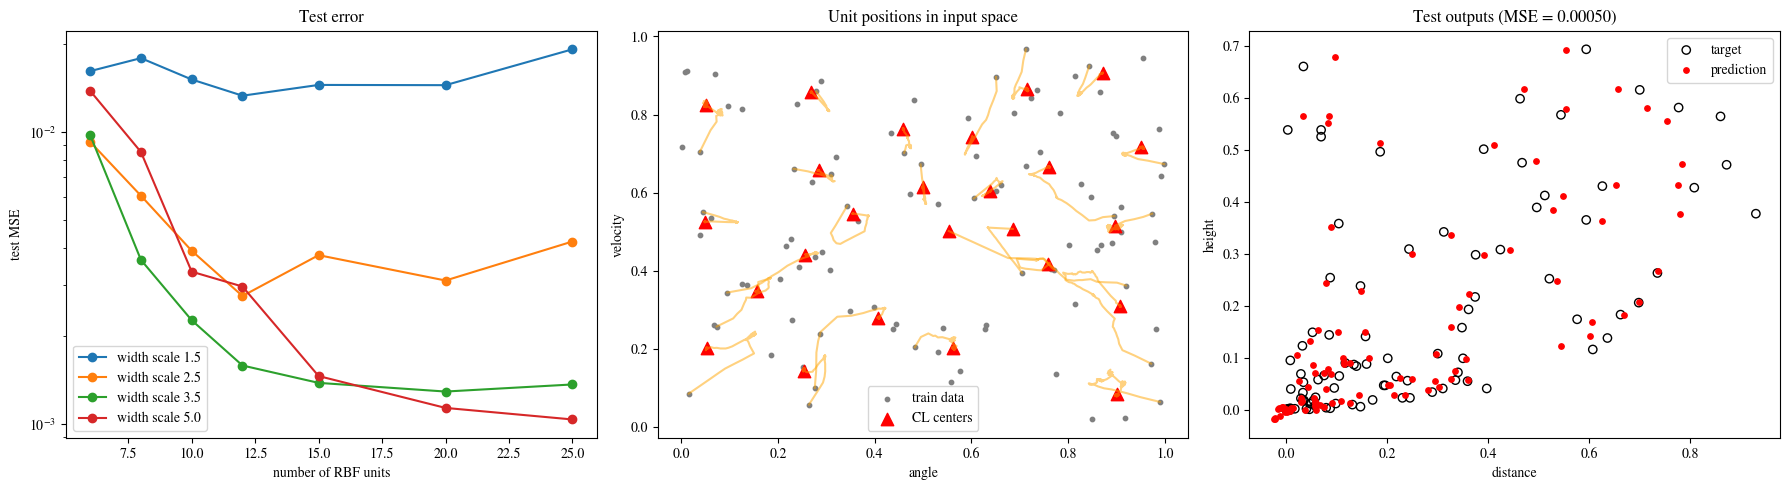

In [36]:
# 3.3 (d) 2D -> 2D RBF network on the ballistic data: (angle, velocity) -> (distance, height)
ball_train = np.loadtxt("./data_lab2/ballist.dat")
ball_test = np.loadtxt("./data_lab2/balltest.dat")
X_ball_train, y_ball_train = ball_train[:, :2], ball_train[:, 2:]
X_ball_test, y_ball_test = ball_test[:, :2], ball_test[:, 2:]

units_list = [6, 8, 10, 12, 15, 20, 25]
width_scales = [1.5, 2.5, 3.5, 5.0]   # width = scale * RMS spread of the cluster
test_errors = np.zeros((len(width_scales), len(units_list)))
for i, scale in enumerate(width_scales):
    for j, n_units in enumerate(units_list):
        centers, _ = competitive_learning(X_ball_train, n_units, epochs=100, leak=0.0005)
        widths = cluster_widths(X_ball_train, centers, scale)
        _, test_mse = delta_rule(rbf_phi(X_ball_train, centers, widths), y_ball_train,
                                 rbf_phi(X_ball_test, centers, widths), y_ball_test, epochs=500)
        test_errors[i, j] = test_mse[-1]
        print(f"units={n_units}, width scale={scale}: test MSE = {test_mse[-1]:.5f}, "
              f"dead units = {count_dead_units(X_ball_train, centers)}")

i, j = np.unravel_index(np.argmin(test_errors), test_errors.shape)
best_scale, best_units = width_scales[i], units_list[j]
print(f"Best: {best_units} units, width scale {best_scale}")

# final model
centers, history = competitive_learning(X_ball_train, best_units, epochs=100, leak=0.0005)
widths = cluster_widths(X_ball_train, centers, best_scale)
PHI_test = rbf_phi(X_ball_test, centers, widths)
W, test_mse = delta_rule(rbf_phi(X_ball_train, centers, widths), y_ball_train,
                         PHI_test, y_ball_test, epochs=1500)
predictions = PHI_test @ W

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, scale in enumerate(width_scales):
    axes[0].semilogy(units_list, test_errors[i], "o-", label=f"width scale {scale}")
axes[0].set_xlabel("number of RBF units")
axes[0].set_ylabel("test MSE")
axes[0].set_title("Test error")
axes[0].legend()

axes[1].scatter(X_ball_train[:, 0], X_ball_train[:, 1], s=10, color="gray", label="train data")
axes[1].plot(history[:, :, 0], history[:, :, 1], color="orange", alpha=0.5)   # CL trajectories
axes[1].scatter(centers[:, 0], centers[:, 1], marker="^", s=80, color="red", label="CL centers")
axes[1].set_xlabel("angle")
axes[1].set_ylabel("velocity")
axes[1].set_title("Unit positions in input space")
axes[1].legend()

axes[2].scatter(y_ball_test[:, 0], y_ball_test[:, 1], facecolors="none", edgecolors="black", label="target")
axes[2].scatter(predictions[:, 0], predictions[:, 1], s=15, color="red", label="prediction")
axes[2].set_xlabel("distance")
axes[2].set_ylabel("height")
axes[2].set_title(f"Test outputs (MSE = {test_mse[-1]:.5f})")
axes[2].legend()
plt.tight_layout()
plt.savefig("imgs/lab2_333.png", dpi=200, bbox_inches="tight")
plt.show()


# 4

In [22]:
from pathlib import Path
import re
#importing files for lab2
paths = ["./data_lab2/animalattributes.txt",
"./data_lab2/animalnames.txt",
"./data_lab2/ballist.dat",
"./data_lab2/balltest.dat",
"./data_lab2/cities.dat",
"./data_lab2/mpnames.txt"]

names = ["animalattributes",
"animalnames",
"ballist",
"balltest",
"cities",
"mpnames"]

animals = np.loadtxt(
    "./data_lab2/animals.dat",
    delimiter = ",",
    dtype = int
).reshape(32,84)

votes = np.loadtxt(
    "./data_lab2/votes.dat",
    delimiter = ",",
    dtype = float
).reshape(349,31)

with open("./data_lab2/mpparty.dat", "r", encoding = "latin-1") as f:
    party = [
        int(line.strip())
        for line in f
        if line.strip() and not line.lstrip().startswith("%")
    ]

with open("./data_lab2/mpdistrict.dat", "r", encoding = "latin-1") as f:
    district = [
        int(line.strip())
        for line in f
        if line.strip() and not line.lstrip().startswith("%")
    ]

with open("./data_lab2/mpsex.dat", "r", encoding = "latin-1") as f:
    sex = [
        int(line.strip())
        for line in f
        if line.strip() and not line.lstrip().startswith("%")
    ]

city = np.array([
    [0.4000, 0.4439],
    [0.2439, 0.1463],
    [0.1707, 0.2293],
    [0.2293, 0.7610],
    [0.5171, 0.9414],
    [0.8732, 0.6536],
    [0.6878, 0.5219],
    [0.8488, 0.3609],
    [0.6683, 0.2536],
    [0.6195, 0.2634]
])

# default, do not change
for name, path in zip(names, paths):
    with open(path, "r", encoding="latin-1") as f:
        globals()[name] = f.read().splitlines()


### 4.1 Topological ordering of animal species

In [23]:
# 4.1 Topological ordering of animal species with a 1D SOM
animal_names = [name.strip().strip("'") for name in animalnames if name.strip()]

n_nodes = 100
epochs = 20
eta = 0.2
radii = np.linspace(50, 1, epochs).round().astype(int)   # neighbourhood shrinks from 50 to 1

rng = np.random.default_rng(0)
som_weights = rng.random((n_nodes, animals.shape[1]))    # 100 x 84, random in [0, 1)
node_index = np.arange(n_nodes)

for epoch in range(epochs):
    for x in animals:
        winner = np.argmin(((som_weights - x) ** 2).sum(axis=1))   # squared euclidean distance
        neighbours = np.abs(node_index - winner) <= radii[epoch]
        som_weights[neighbours] += eta * (x - som_weights[neighbours])

# find the winning node of each animal and sort
pos = np.array([np.argmin(((som_weights - x) ** 2).sum(axis=1)) for x in animals])
for i in np.argsort(pos):
    print(pos[i], animal_names[i])


0 grasshopper
0 dragonfly
1 beetle
4 butterfly
6 moskito
8 housefly
13 spider
20 pelican
23 duck
28 penguin
31 ostrich
38 frog
43 seaturtle
45 crocodile
52 walrus
57 bear
59 hyena
61 dog
66 lion
68 ape
70 cat
75 skunk
77 bat
82 rat
87 rabbit
89 elephant
91 kangaroo
94 antelop
97 horse
97 pig
99 giraffe
99 camel


<Figure size 640x480 with 0 Axes>

## 4.3 Data clustering: votes of MPs

In [24]:
assert((349, 31) == votes.shape)
assert(349 == len(party))
assert(len(mpnames) == 349)

In [5]:
number_features = 31
number_rows = 10
number_columns = 10


In [7]:
# find the winning node and return its row and column in the grid
def winner(x, weights):
    distances = np.sum((weights - x) ** 2, axis = 2)
    winner_node = np.unravel_index(np.argmin(distances), distances.shape)
    return winner_node

In [27]:
# make a matrix with neighbours as 1s
def neighbourhood_matrix(winner_node, neighbourhood_distance, rows=10, columns=10):
    x, y = winner_node
    matrix = np.zeros((rows, columns), dtype = bool)

    for row in range(rows):
        for column in range(columns):
            distance = abs(row - x) + abs(column - y)
            if distance <= neighbourhood_distance:
                matrix[row, column] = True
    return matrix
assert np.array_equal(neighbourhood_matrix((1, 1), 1, 3, 3), np.array([[0, 1, 0], [1, 1, 1], [0, 1, 0]]))

In [30]:
# SOM update rule
def update(weights, x, winner, neighbourhood_distance, mult):
    neighbourhood_matrix_result = neighbourhood_matrix(winner, neighbourhood_distance, weights.shape[0], weights.shape[1])
    weights[neighbourhood_matrix_result] += mult * (x - weights[neighbourhood_matrix_result])

    return weights

In [32]:
# training
def train(data, rows = 10, columns = 10, mult = 0.2, distance_initial = 5, distance_final = 0, epochs = 50):
    number_samples, number_features = data.shape
    # init weights for a 10x10 grid
    weights = np.random.rand(rows, columns, number_features)
    for epoch in range(epochs):
        ratio = epoch / epochs
        distance = (distance_initial + ratio * (distance_final - distance_initial))
        shuffled = np.random.permutation(number_samples)
        for i in shuffled:
            x = data[i]
            winning_node = winner(x, weights)
            distance = int(distance)
            weights = update(weights, x, winning_node, distance, mult)

    return weights


In [25]:
weights = train(votes)
print(weights.shape)

NameError: name 'train' is not defined

In [39]:
result_map = np.array([winner(x, weights) for x in votes])
print(result_map.shape)

NameError: name 'weights' is not defined

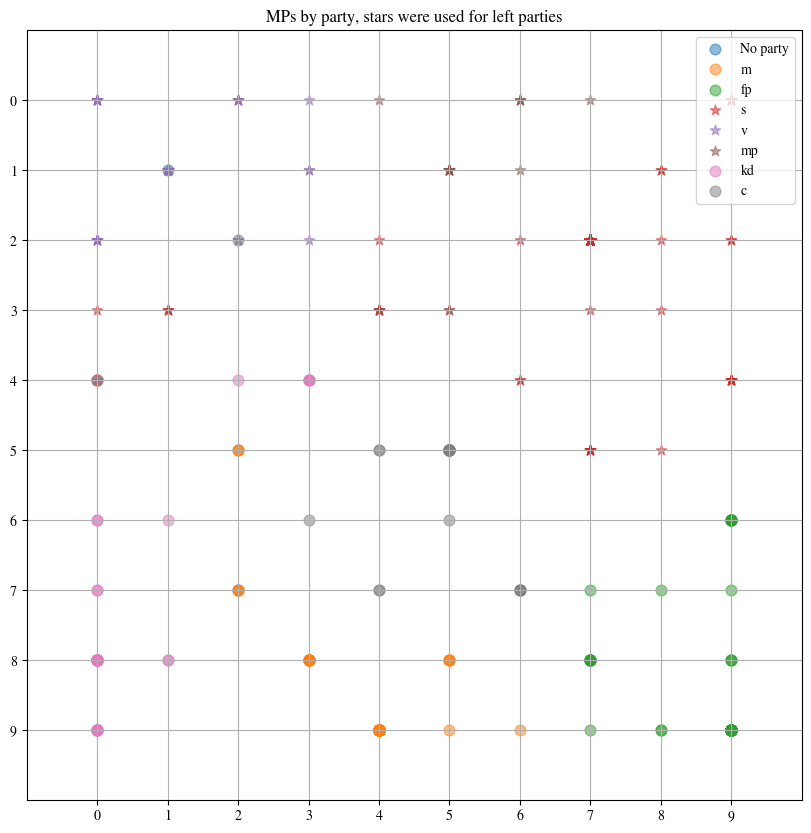

In [27]:
party_codes = {
    0: "No party",
    1: "m",
    2: "fp",
    3: "s",
    4: "v",
    5: "mp",
    6: "kd",
    7: "c"
}
plt.figure(figsize = (10, 10))
for party_num in sorted(set(party)):
    order = [
        i for i, value in enumerate(party)
        if value == party_num
    ]
    coords = result_map[order]
    if party_num == 3 or party_num == 4 or party_num ==5:
        marker = "*"
    else:
        marker = "o"
    plt.scatter(
        coords[:, 1],
        coords[:, 0],
        label = party_codes[party_num],
        s = 60,
        marker = marker,
        alpha=0.5
    )
plt.xlim(-1, 10)
plt.ylim(10, -1)

plt.xticks(range(10))
plt.yticks(range(10))
plt.grid(True)
plt.legend()
plt.title("MPs by party, stars were used for left parties")

plt.show()

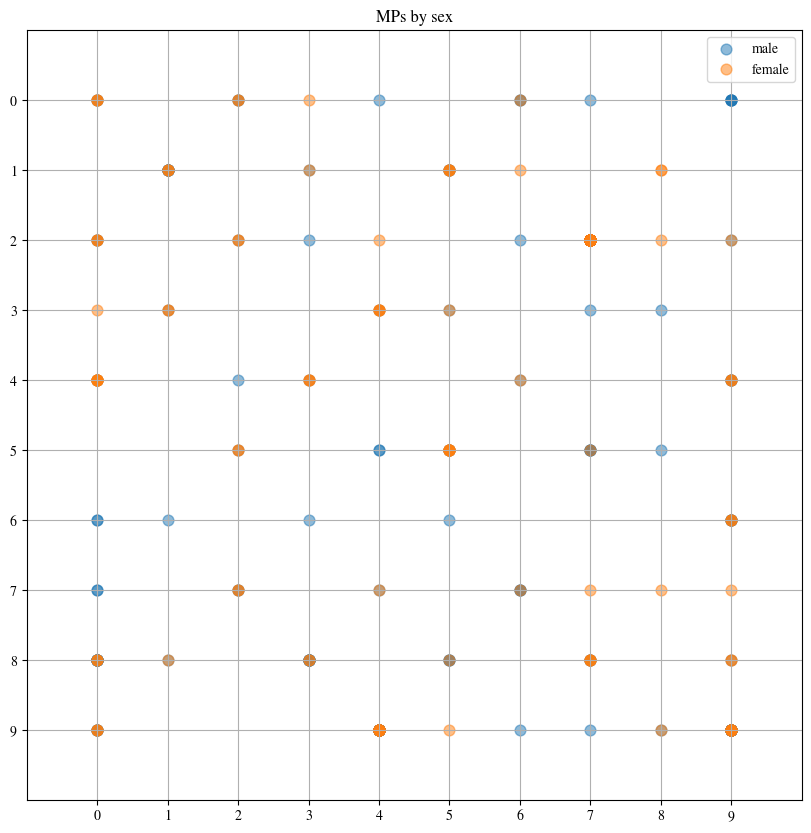

In [28]:
sex_codes = {
    0: "male",
    1: "female",
}
plt.figure(figsize = (10, 10))
for sex_num in sorted(set(sex)):
    order = [
        i for i, value in enumerate(sex)
        if value == sex_num
    ]
    coords = result_map[order]
    plt.scatter(
        coords[:, 1],
        coords[:, 0],
        label = sex_codes[sex_num],
        s = 60,
        alpha = 0.5
    )
plt.xlim(-1, 10)
plt.ylim(10, -1)
plt.legend()
plt.xticks(range(10))
plt.yticks(range(10))
plt.grid(True)
plt.title("MPs by sex")

plt.show()

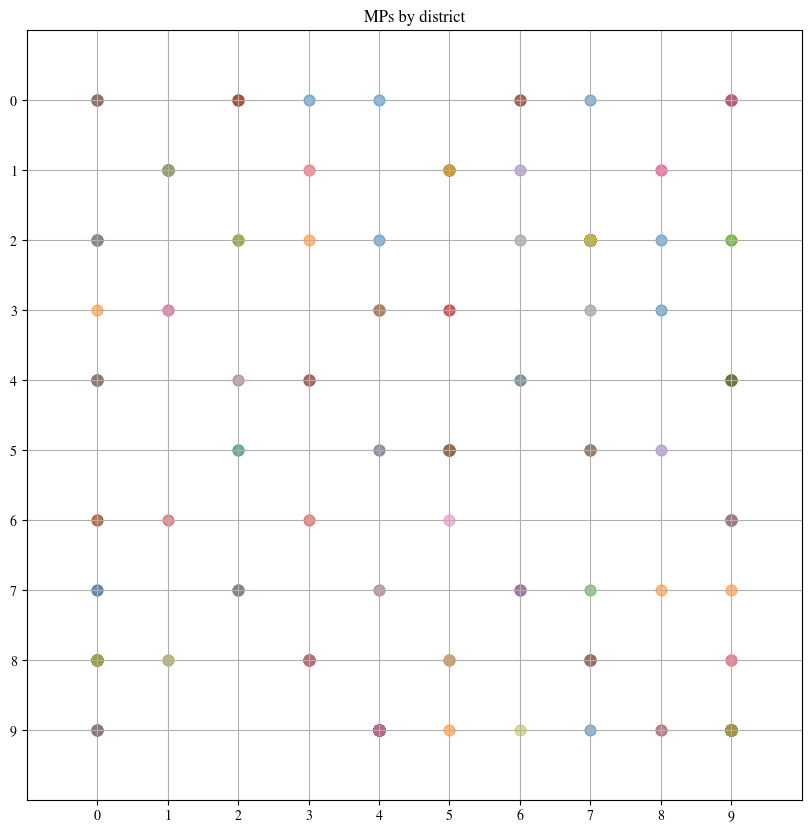

In [29]:
plt.figure(figsize = (10, 10))
for district_num in sorted(set(district)):
    order = [
        i for i, value in enumerate(district)
        if value == district_num
    ]
    coords = result_map[order]
    plt.scatter(
        coords[:, 1],
        coords[:, 0],
        label = district_num,
        s = 60,
        alpha = 0.5
    )
plt.xlim(-1, 10)
plt.ylim(10, -1)

plt.xticks(range(10))
plt.yticks(range(10))
plt.grid(True)
plt.title("MPs by district")

plt.show()

## 4.2 Cyclic tour

In [73]:
def winner(x, weights):
    distances = np.sum((weights - x) ** 2, axis = 2)
    return np.argmin(distances)

In [70]:
# make a matrix with neighbours as 1s
def neighbourhood_matrix(winner_node, neighbourhood_distance, rows=10, columns = 1):
    matrix = np.zeros((rows, columns), dtype = bool)

    for row in range(rows):
        distance = min(abs(row - winner_node), rows - abs(row - winner_node))
        if distance <= neighbourhood_distance:
            matrix[row, 0] = True
    return matrix

In [71]:
print(neighbourhood_matrix(0, 1))

[[ True]
 [ True]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [ True]]


In [137]:
weights = train(city, rows = 20, columns = 1, mult = 0.2, distance_initial = 4, distance_final = 0, epochs = 100)

In [138]:
path = weights[:, 0, :]
print(path.shape)

(20, 2)


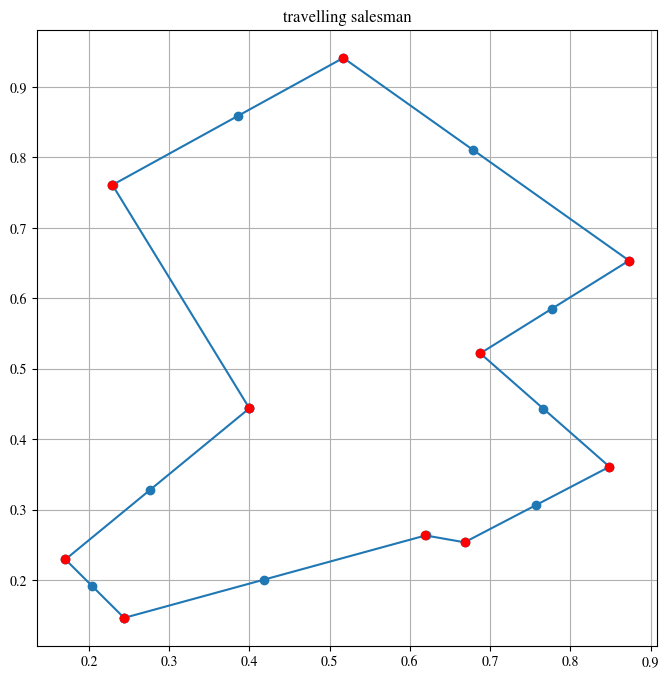

In [139]:
plt.figure(figsize = (8, 8))

path = np.vstack([path, path[0]])

plt.plot(path[:, 0], path[:, 1], "-o")
plt.scatter(city[:, 0], city[:, 1], color = "red", zorder = 3)
plt.grid(True)

plt.title("travelling salesman")

plt.show()